In [1]:
"""
═══════════════════════════════════════════════════════════════════════════════
        MARKET TIMING BACKTEST FRAMEWORK  —  v7
        Per-stock Independence  ·  Weighted Portfolio  ·  Regime Report
═══════════════════════════════════════════════════════════════════════════════

STRUCTURE
─────────
  1.  Data        — load_prices()
  2.  Regime      — regime_probabilities()   [read-only diagnostic, 4 votes]
                    regime_report()          [run first to guide strategy choice]
  3.  Signals     — signal_sma_crossover()
                    signal_rsi()
                    signal_volatility_regime()
                    signal_drawdown_guard()
                    signal_bollinger_reversion()
                    signal_combined()        [generalised majority-vote combiner]
  4.  Loss stops  — apply_trailing_stop()   [dynamic, ratchets with price]
                    apply_static_stop()     [fixed at entry price]
  5.  Backtest    — backtest_single()        [full per-stock backtest]
                    backtest_portfolio()     [weighted aggregation of per-stock results]
  6.  Reporting   — performance()           [portfolio + per-stock + regime table]
                    one_day_forecast()      [tomorrow's action with weights]
  7.  Plot        — plot()
  8.  Main        — main()

KEY DESIGN DECISIONS
────────────────────
  • Run regime_report() first to understand each stock's regime probabilities,
    then choose signal functions accordingly — the framework never forces a
    strategy on you.
  • Every stock is completely independent: its own signal_list, its own stop,
    its own NAV, its own performance metrics.
  • Weights are used consistently across the backtest, performance report,
    and 1-day forecast (including allocated dollar amounts per ticker).
  • Weights are FIXED for the full backtest period — no capital rebalancing
    between stocks occurs over time.  Dollar allocations drift with returns.

DEPENDENCIES
────────────
    pip install numpy pandas matplotlib yfinance

USAGE
─────
    python market_timing.py
"""

from __future__ import annotations

import warnings
from typing import Callable, Dict, List, Optional
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import random

warnings.filterwarnings("ignore")


# ─────────────────────────────────────────────────────────────────────────────
# 1. DATA
# ─────────────────────────────────────────────────────────────────────────────

def load_prices(tickers: List[str], start: str, end: str) -> pd.DataFrame:
    """
    Download daily adjusted-close prices from Yahoo Finance.

    Args:
        tickers: Yahoo Finance ticker symbols, e.g. ``["SPY", "QQQ", "GLD"]``.
        start:   Inclusive start date in ``"YYYY-MM-DD"`` format.
        end:     Exclusive end date in ``"YYYY-MM-DD"`` format.

    Returns:
        pd.DataFrame: Columns = tickers, index = trading dates (business days).
        Forward-fills up to 5 consecutive missing values to handle exchange-
        specific holidays, then drops any ticker with more than 10 % NaN.

    Raises:
        RuntimeError: If yfinance is not installed or the download fails.
    """
    try:
        import yfinance as yf
    except:
        raise RuntimeError("yfinance is required:  pip install yfinance")

    raw = yf.download(tickers, start=start, end=end, auto_adjust=True, progress=False)

    prices = (raw["Close"] if isinstance(raw.columns, pd.MultiIndex)
              else raw[["Close"]].rename(columns={"Close": tickers[0]}))

    prices.columns = [str(c) for c in prices.columns]
    prices = prices.ffill(limit=5)
    prices = prices.dropna(axis=1, thresh=int(len(prices) * 0.90))

    dropped = set(tickers) - set(prices.columns)
    if dropped:
        print(f"[load_prices] Dropped (>10% missing): {dropped}")
    print(f"[load_prices] Loaded {len(prices.columns)} tickers × {len(prices)} days.")
    return prices


# ─────────────────────────────────────────────────────────────────────────────
# 2. PROBABILISTIC REGIME DETECTOR  (diagnostic only — does not drive signals)
# ─────────────────────────────────────────────────────────────────────────────

def regime_probabilities(
    prices:        pd.Series,
    hurst_win:     int = 100,
    hurst_split:   int = 4,
    trend_fast:    int = 50,
    trend_slow:    int = 200,
    autocorr_lag:  int = 5,
    vol_ratio_win: int = 21,
    vol_long_win:  int = 126,
) -> Dict:
    """
    Estimate whether a stock's most recent price behaviour is consistent with
    a **trending** or **mean-reverting** regime.

    Four independent statistical signals each cast a vote:

    (a) **Hurst variance-ratio proxy** — Var(long window) / Var(short sub-window).
        Ratio > ``hurst_split`` implies return persistence (trending).
    (b) **SMA separation** — normalised gap between a fast and slow moving
        average.  Gap above its historical median implies a trend in place.
    (c) **Return autocorrelation** — positive autocorrelation at ``autocorr_lag``
        implies momentum; negative implies mean-reversion.
    (d) **Volatility ratio** — short-run vol / medium-run vol.  Elevated
        short-vol is associated with directional breakouts (trending).

    The probability of trending is the fraction of votes that favour trending.

    Args:
        prices:        Daily close price series for a single ticker.
        hurst_win:     Full window for the Hurst variance-ratio (default 100).
        hurst_split:   Sub-window divisor; also the ratio threshold (default 4).
        trend_fast:    Fast SMA window in days (default 50).
        trend_slow:    Slow SMA window in days (default 200).
        autocorr_lag:  Autocorrelation lag in days (default 5).
        vol_ratio_win: Short vol window in days (default 21).
        vol_long_win:  Medium vol window in days (default 126).

    Returns:
        dict:
            ``"p_trend"``  — probability of trending regime (0.0–1.0).
            ``"p_revert"`` — probability of mean-reverting regime (0.0–1.0).
            ``"label"``    — ``"Trending"`` if p_trend ≥ 0.5 else ``"Reverting"``.
            ``"signals"``  — individual vote dict (key → +1 trending / -1 reverting).

    Notes:
        - No look-ahead bias: uses only data up to and including the last row.
        - Signals that cannot be computed (insufficient history) are omitted
          from the vote pool rather than filled with a default.
        - This function is **purely diagnostic**.  It is not used by
          ``backtest_single`` or ``backtest_portfolio`` in any way.
    """
    log_ret = np.log(prices / prices.shift(1)).dropna()
    votes: Dict[str, int] = {}

    # (a) Hurst variance-ratio
    sub_win = hurst_win // hurst_split
    if len(log_ret) >= hurst_win and log_ret.iloc[-sub_win:].var() > 0:
        ratio = log_ret.iloc[-hurst_win:].var() / log_ret.iloc[-sub_win:].var()
        votes["hurst"] = 1 if ratio > hurst_split else -1

    # (b) SMA separation
    if len(prices) >= trend_slow * 2:
        sma_gap = ((prices.rolling(trend_fast).mean() - prices.rolling(trend_slow).mean())
                   .abs() / prices.rolling(trend_slow).mean()).dropna()
        if len(sma_gap):
            votes["sma_sep"] = 1 if sma_gap.iloc[-1] > sma_gap.median() else -1

    # (c) Return autocorrelation
    if len(log_ret) >= autocorr_lag + 30:
        ac = log_ret.autocorr(lag=autocorr_lag)
        if not np.isnan(ac):
            votes["autocorr"] = 1 if ac > 0 else -1

    # (d) Volatility ratio
    if len(log_ret) >= vol_long_win and log_ret.iloc[-vol_long_win:].std() > 0:
        vr = log_ret.iloc[-vol_ratio_win:].std() / log_ret.iloc[-vol_long_win:].std()
        votes["vol_ratio"] = 1 if vr > 1.1 else -1

    if not votes:
        return {"p_trend": 0.5, "p_revert": 0.5, "label": "Uncertain", "signals": {}}

    p_trend = sum(1 for v in votes.values() if v == 1) / len(votes)
    return {
        "p_trend":  round(p_trend, 3),
        "p_revert": round(1 - p_trend, 3),
        "label":    "Trending" if p_trend >= 0.5 else "Reverting",
        "signals":  votes,
    }


def regime_report(prices: pd.DataFrame) -> pd.DataFrame:
    """
    Compute and print a regime-probability table for every ticker.

    This is a read-only diagnostic: the numbers here do not influence the
    backtest.  Use them to guide your choice of signal functions per ticker.

    Args:
        prices: Multi-ticker close price DataFrame (from ``load_prices``).

    Returns:
        pd.DataFrame: One row per ticker with columns ``p_trend``,
        ``p_revert``, ``label``, and one column per signal vote.
    """
    rows = []
    for ticker in prices.columns:
        info = regime_probabilities(prices[ticker].dropna())
        row  = {"ticker": ticker, "p_trend": info["p_trend"],
                "p_revert": info["p_revert"], "label": info["label"]}
        for k, v in info["signals"].items():
            row[k] = "t" if v == 1 else "r"
        rows.append(row)

    df       = pd.DataFrame(rows).set_index("ticker")
    sig_cols = [c for c in df.columns if c not in ("p_trend", "p_revert", "label")]

    print(f"\n{'═' * 72}")
    print(f"  REGIME PROBABILITY REPORT")
    print(f"{'═' * 72}")
    hdr = f"  {'Ticker':<8} {'p_trend':>8} {'p_revert':>9} {'Label':>11}"
    for s in sig_cols:
        hdr += f"  {s:>9}"
    print(hdr)
    print(f"  {'─' * 70}")
    for t, row in df.iterrows():
        line = f"  {t:<8} {row['p_trend']:>8.1%} {row['p_revert']:>9.1%} {row['label']:>11}"
        for s in sig_cols:
            line += f"  {row.get(s, '—'):>9}"
        print(line)
    print(f"{'═' * 72}\n")
    return df


# ─────────────────────────────────────────────────────────────────────────────
# 3. SIGNALS  (each returns a 0/1 pd.Series; all long-only)
# ─────────────────────────────────────────────────────────────────────────────

def signal_buy_and_hold(prices: pd.Series) -> pd.Series:
    """
    Buy-and-hold signal — always invested.

    Always returns 1 for every bar. Use this as a benchmark strategy
    to compare any active signal against a pure passive holding.
    No parameters to tune.

    Args:
        prices: Daily close price series.

    Returns:
        pd.Series: Binary signal (all 1s) named "BuyAndHold".
    """
    return pd.Series(np.ones(len(prices), dtype=int),
                     index=prices.index, name="BuyAndHold")


def signal_sma_crossover(
    prices: pd.Series,
    fast: int = 50,
    slow: int = 200,
    trend_window: int = 100,
    buffer: float = 0.01,
    slope_window: int = 5,
    slope_threshold: float = 0.0,
) -> pd.Series:
    """
    SMA crossover strategy with buffer, slope filter, and macro trend filter.

    Enhancements over basic crossover:
        (1) Buffer zone reduces whipsaw near crossover
        (2) Slow SMA slope confirms momentum
        (3) Trend filter ensures trades align with macro regime

    Signal logic:
        ENTER (1) when:
            - fast SMA > slow SMA * (1 + buffer)
            - slow SMA slope > slope_threshold
            - price > trend SMA (macro trend filter)

        EXIT (0) when:
            - fast SMA < slow SMA * (1 - buffer)
            OR price < trend SMA

    Args:
        prices:          Price series
        fast:            Fast SMA window
        slow:            Slow SMA window
        trend_window:    Macro trend filter window (NEW)
        buffer:          Separation buffer for crossover confirmation
        slope_window:    Window for slope estimation
        slope_threshold: Minimum slope for trend confirmation

    Returns:
        pd.Series: Binary position signal (0/1)
    """

    fast_sma = prices.rolling(fast).mean()
    slow_sma = prices.rolling(slow).mean()
    trend_sma = prices.rolling(trend_window).mean()

    slow_slope = slow_sma.diff(slope_window)

    pos = np.zeros(len(prices))
    in_mkt = False

    for i in range(len(prices)):
        f = fast_sma.iloc[i]
        s = slow_sma.iloc[i]
        t = trend_sma.iloc[i]
        slope = slow_slope.iloc[i]
        p = prices.iloc[i]

        if np.isnan(f) or np.isnan(s) or np.isnan(t) or np.isnan(slope):
            pos[i] = 0
            continue

        trend_ok = p > t

        if not in_mkt:
            if (f > s * (1 + buffer)) and (slope > slope_threshold) and trend_ok:
                in_mkt = True
        else:
            if (f < s * (1 - buffer)) or (p < t):
                in_mkt = False

        pos[i] = int(in_mkt)

    return pd.Series(pos, index=prices.index, name="SMA_Crossover")


def signal_rsi(
    prices: pd.Series, window: int = 14, oversold: int = 35, overbought: int = 75,
) -> pd.Series:
    """
    RSI mean-reversion timing signal (stateful).

    Rule: enter (1) when RSI < ``oversold``; exit (0) when RSI > ``overbought``.
    Holds previous position in between to avoid mid-range whipsawing.

    Works well when price oscillates around a mean without a clear trend.

    Args:
        prices:     Daily close price series.
        window:     RSI period in trading days (default 14).
        oversold:   Buy threshold — RSI below this level triggers entry (default 35).
        overbought: Sell threshold — RSI above this level triggers exit (default 75).

    Returns:
        pd.Series: Binary signal (0/1) named ``"RSI"``.

    Notes:
        - Initialises OUT of market (in_mkt=False) so no position is taken
          before a valid oversold signal fires.  This prevents spurious
          exposure during the warm-up period.
        - When all recent moves are losses, gain=0 → RSI=0 (correct: extreme
          oversold).  When all moves are gains, loss=0 → RSI=100 (correct:
          extreme overbought) via the np.nan replacement in the denominator.
    """
    delta = prices.diff()
    gain  = delta.clip(lower=0).rolling(window).mean()
    loss  = (-delta.clip(upper=0)).rolling(window).mean()
    rsi   = 100 - (100 / (1 + gain / loss.replace(0, np.nan)))

    # FIX BUG-1: start OUT of market; only enter on a real oversold signal.
    pos, in_mkt = np.zeros(len(prices)), False
    for i in range(len(prices)):
        r = rsi.iloc[i]
        if not np.isnan(r):
            if   r < oversold:   in_mkt = True
            elif r > overbought: in_mkt = False
        pos[i] = int(in_mkt)
    return pd.Series(pos, index=prices.index, name="RSI")


def signal_volatility_regime(
    prices: pd.Series, short_window: int = 21, long_window: int = 252, threshold: float = 1.3,
) -> pd.Series:
    """
    Volatility regime filter — moves to cash when short-run vol spikes.

    Rule: IN (1) when 21-day vol < ``threshold`` × 252-day vol; OUT (0) otherwise.

    Useful as a defensive overlay: it filters out high-uncertainty periods
    regardless of the direction of the primary trend signal.

    Args:
        prices:       Daily close price series.
        short_window: Short-run vol window in days (default 21).
        long_window:  Long-run vol baseline window in days (default 252).
        threshold:    Ratio above which vol is considered elevated (default 1.3).

    Returns:
        pd.Series: Binary signal (0/1) named ``"VolRegime"``.
    """
    r = prices.pct_change()
    s = r.rolling(short_window).std() * np.sqrt(252)
    l = r.rolling(long_window).std()  * np.sqrt(252)
    return (s < l * threshold).astype(int).rename("VolRegime")


def signal_drawdown_guard(prices: pd.Series, max_dd: float = 0.10) -> pd.Series:
    """
    Trailing drawdown guard — exits when price drops too far from its peak.

    Rule: IN (1) when drawdown from rolling peak < ``max_dd``; OUT (0) otherwise.

    Acts as a trailing risk filter: it never prevents entry, but it forces
    an exit once a loss threshold from the high-water mark is breached.

    Args:
        prices: Daily close price series.
        max_dd: Maximum tolerated drawdown from peak (default 0.10 = 10%).

    Returns:
        pd.Series: Binary signal (0/1) named ``"DrawdownGuard"``.
    """
    dd = (prices - prices.cummax()) / prices.cummax()
    return (dd > -max_dd).astype(int).rename("DrawdownGuard")


def signal_bollinger_reversion(
    prices: pd.Series,
    window: int = 20,
    n_std: float = 2.0,
    bw_window: int = 50,
    bw_quantile: float = 0.5,
) -> pd.Series:
    """
    Bollinger Band mean-reversion signal with optional bandwidth filter (stateful).

    Philosophy:
        In low-volatility, range-bound regimes, price tends to revert toward
        its moving average after deviating to extremes. Touches of the lower
        band are treated as oversold conditions rather than the start of a trend.

    Rule:
        - Enter (1) when:
            price <= lower band AND bandwidth < rolling quantile threshold
        - Exit (0) when:
            price >= middle band
        - Hold position otherwise (stateful)

    Args:
        prices:       Daily close price series.
        window:       Rolling window for Bollinger Bands (default 20).
        n_std:        Band width in standard deviations (default 2.0).
        bw_window:    Rolling window for bandwidth threshold (default 50).
        bw_quantile:  Upper quantile threshold for "low volatility" regime
                      (default 0.5 = median).

    Returns:
        pd.Series: Binary signal (0/1) named "BollingerReversion".

    Notes:
        - Bandwidth = (upper - lower) / middle.
        - The bandwidth filter suppresses trades during volatility expansion,
          where mean-reversion is less reliable.
        - Initialises OUT of market (in_mkt=False).
        - No look-ahead bias: all rolling statistics use past data only.
        - Stateful design avoids repeated entry/exit within the band.
    """
    mid   = prices.rolling(window).mean()
    std   = prices.rolling(window).std()
    upper = mid + n_std * std
    lower = mid - n_std * std

    bandwidth = (upper - lower) / mid
    bw_thresh = bandwidth.rolling(bw_window).quantile(bw_quantile)

    pos = np.zeros(len(prices))
    in_mkt = False

    for i in range(len(prices)):
        p  = prices.iloc[i]
        m  = mid.iloc[i]
        l  = lower.iloc[i]
        bw = bandwidth.iloc[i]
        bt = bw_thresh.iloc[i]

        if not np.isnan(l) and not np.isnan(bt):
            if not in_mkt:
                if p <= l and bw < bt:
                    in_mkt = True
            else:
                if p >= m:
                    in_mkt = False

        pos[i] = int(in_mkt)

    return pd.Series(pos, index=prices.index, name="BollingerReversion")


def signal_bollinger_trend(
    prices: pd.Series,
    window: int = 20,
    n_std: float = 2.0,
    bw_window: int = 50,
    bw_quantile: float = 0.6,
) -> pd.Series:
    """
    Bollinger Band trend-following signal with bandwidth filter.

    Philosophy:
        In trending regimes, price tends to "ride" the upper band. A breakout
        above the upper band combined with elevated bandwidth (volatility
        expansion) signals trend continuation rather than exhaustion.

    Rule:
        - Enter (1) when:
            price > upper band AND bandwidth > rolling quantile threshold
        - Exit (0) when:
            price falls below the middle band
        - Hold position otherwise (stateful)

    Args:
        prices:       Daily close price series.
        window:       Rolling window for Bollinger Bands (default 20).
        n_std:        Band width in standard deviations (default 2.0).
        bw_window:    Rolling window for bandwidth threshold (default 50).
        bw_quantile:  Quantile threshold for bandwidth expansion (default 0.6).

    Returns:
        pd.Series: Binary signal (0/1) named "BollingerTrend".

    Notes:
        - Bandwidth = (upper - lower) / middle.
        - Uses rolling quantile of bandwidth to detect volatility expansion.
        - Initialises OUT of market (in_mkt=False) until a valid breakout occurs.
        - No look-ahead bias: all rolling statistics use past data only.
    """
    mid   = prices.rolling(window).mean()
    std   = prices.rolling(window).std()
    upper = mid + n_std * std
    lower = mid - n_std * std

    bandwidth = (upper - lower) / mid
    bw_thresh = bandwidth.rolling(bw_window).quantile(bw_quantile)

    pos = np.zeros(len(prices))
    in_mkt = False

    for i in range(len(prices)):
        p  = prices.iloc[i]
        u  = upper.iloc[i]
        m  = mid.iloc[i]
        bw = bandwidth.iloc[i]
        bt = bw_thresh.iloc[i]

        if not np.isnan(u) and not np.isnan(bt):
            if not in_mkt:
                if p > u and bw > bt:
                    in_mkt = True
            else:
                if p < m:
                    in_mkt = False

        pos[i] = int(in_mkt)

    return pd.Series(pos, index=prices.index, name="BollingerTrend")


def signal_bollinger_adaptive(
    prices: pd.Series,
    window: int = 20,
    n_std: float = 2.0,
    bw_window: int = 50,
    bw_quantile: float = 0.5,
) -> pd.Series:
    """
    Adaptive Bollinger Band strategy based on bandwidth regime.

    Combines trend-following and mean-reversion behaviour depending on
    the current volatility regime as measured by Bollinger Bandwidth.

    Regime logic:
        - LOW bandwidth (below quantile)  → TREND mode
        - HIGH bandwidth (above quantile) → MEAN-REVERSION mode

    Strategy rules:
        TREND mode:
            - IN (1) when price breaks above upper band
            - OUT (0) when price falls below middle band

        REVERSION mode:
            - IN (1) when price touches lower band
            - OUT (0) when price crosses above middle band

    Args:
        prices:        Daily close price series.
        window:        Rolling window for Bollinger Bands (default 20).
        n_std:         Band width in standard deviations (default 2.0).
        bw_window:     Lookback window for bandwidth distribution (default 50).
        bw_quantile:   Quantile threshold for regime split (0–1, default 0.5).

    Returns:
        pd.Series: Binary signal (0/1) named "BollingerAdaptive".

    Notes:
        - Stateful signal: holds position between entry/exit triggers.
        - Starts OUT of market until first valid signal.
        - Uses rolling quantile → no look-ahead bias.
    """
    mid   = prices.rolling(window).mean()
    std   = prices.rolling(window).std()
    upper = mid + n_std * std
    lower = mid - n_std * std

    # Bollinger Bandwidth
    bandwidth = (upper - lower) / mid

    # Rolling quantile threshold (no look-ahead)
    bw_thresh = bandwidth.rolling(bw_window).quantile(bw_quantile)

    pos = np.zeros(len(prices))
    in_mkt = False

    for i in range(len(prices)):
        p  = prices.iloc[i]
        m  = mid.iloc[i]
        u  = upper.iloc[i]
        l  = lower.iloc[i]
        bw = bandwidth.iloc[i]
        th = bw_thresh.iloc[i]

        if np.isnan(th):
            pos[i] = 0
            continue

        # Regime classification
        is_trend = bw < th   # low vol → trend

        if is_trend:
            # TREND MODE
            if not np.isnan(u):
                if p > u:
                    in_mkt = True
                elif p < m:
                    in_mkt = False
        else:
            # REVERSION MODE
            if not np.isnan(l):
                if p < l:
                    in_mkt = True
                elif p > m:
                    in_mkt = False

        pos[i] = int(in_mkt)

    return pd.Series(pos, index=prices.index, name="BollingerAdaptive")

def signal_combined(
    prices:         pd.Series,
    signal_list:    Optional[List] = None,
    vote_threshold: int = 2,
) -> pd.Series:
    """
    Majority-vote ensemble of an arbitrary list of signal functions with
    their own parameters.

    Each entry in ``signal_list`` is either:

    * A bare callable  ``f``           — called as ``f(prices)``
    * A ``(callable, kwargs)`` tuple   — called as ``f(prices, **kwargs)``

    The second form lets you tune every signal's parameters individually,
    which is essential for parameter search (e.g. grid search over RSI
    window, SMA periods, vol threshold, etc.).

    Args:
        prices:         Daily close price series.
        signal_list:    List of signal specifications.  Each element is either
                        a plain callable or a ``(callable, dict)`` pair where
                        the dict holds keyword arguments forwarded to that
                        signal function.  Defaults to the four standard signals
                        with their default parameters.
        vote_threshold: Minimum number of agreeing signals needed to be IN
                        market (default 2).

    Returns:
        pd.Series: Binary signal (0/1) named ``"Combined_<N>"`` where N is
        the number of signal specifications supplied.

    Examples::

        # Bare callables — each uses its own default parameters:
        sig = signal_combined(
            prices,
            signal_list    = [signal_sma_crossover, signal_volatility_regime],
            vote_threshold = 1,
        )

        # Tuned parameters — (callable, kwargs) tuple per signal:
        sig = signal_combined(
            prices,
            signal_list = [
                (signal_sma_crossover,     {"fast": 20, "slow": 100}),
                (signal_rsi,               {"window": 10, "oversold": 30, "overbought": 70}),
                (signal_volatility_regime, {"threshold": 1.5}),
            ],
            vote_threshold = 2,
        )

        # Mix bare callables and tuned pairs freely:
        sig = signal_combined(
            prices,
            signal_list = [
                signal_drawdown_guard,                           # default max_dd=0.10
                (signal_sma_crossover, {"fast": 30, "slow": 150}),
            ],
            vote_threshold = 1,
        )
    """
    if signal_list is None:
        signal_list = [signal_sma_crossover, signal_rsi,
                       signal_volatility_regime, signal_drawdown_guard]

    votes = pd.Series(0.0, index=prices.index)
    for entry in signal_list:
        if callable(entry):
            signal_fn, kwargs = entry, {}
        else:
            signal_fn, kwargs = entry
        votes += signal_fn(prices, **kwargs).reindex(prices.index).fillna(0)

    return (votes >= vote_threshold).astype(int).rename(f"Combined_{len(signal_list)}")


# ─────────────────────────────────────────────────────────────────────────────
# 4. LOSS STOPS
# ─────────────────────────────────────────────────────────────────────────────

def apply_trailing_stop(
    prices: pd.Series, signal: pd.Series, trail_pct: float = 0.07, cooldown: int = 5,
) -> pd.Series:
    """
    Dynamic trailing stop-loss.

    After entry the stop tracks the highest close observed.  If the price
    falls ``trail_pct`` below that trailing high, the position closes and a
    ``cooldown`` lockout prevents re-entry for a fixed number of days.

    Suitable as the default stop for trend-following signals where profits
    need to be protected as the trend matures.

    Args:
        prices:    Daily close price series.
        signal:    Base binary signal (0/1) to be wrapped.
        trail_pct: Percentage drop from trailing high that triggers the stop
                   (default 0.07 = 7%).
        cooldown:  Trading days to stay in cash after a stop fires (default 5).

    Returns:
        pd.Series: Modified binary signal named ``"<base>_TrailStop"``.

    Notes:
        - Long-only: the stop can only force an exit, never create an entry.
        - The trailing high resets each time the strategy re-enters.
        - Signal must be binary (0/1); fractional values will raise ValueError.
    """
    sig = signal.reindex(prices.index).ffill().fillna(0)

    # WARN-2: guard against fractional signals — cost math assumes binary 0/1.
    unique_vals = set(sig.unique())
    if not unique_vals.issubset({0, 1, 0.0, 1.0}):
        raise ValueError(
            f"apply_trailing_stop requires a binary 0/1 signal; "
            f"got unique values: {unique_vals}"
        )

    out, trail_hi, cd = np.zeros(len(prices)), np.nan, 0

    for i in range(len(prices)):
        p, base = prices.iloc[i], sig.iloc[i]
        if cd > 0:
            cd -= 1; out[i] = 0; trail_hi = np.nan; continue
        if base == 0:
            out[i] = 0; trail_hi = np.nan; continue
        trail_hi = p if np.isnan(trail_hi) else max(trail_hi, p)
        if p < trail_hi * (1 - trail_pct):
            out[i] = 0; trail_hi = np.nan; cd = cooldown
        else:
            out[i] = 1

    return pd.Series(out, index=prices.index, name=f"{signal.name}_TrailStop")


def apply_static_stop(
    prices: pd.Series, signal: pd.Series, stop_pct: float = 0.05, cooldown: int = 3,
) -> pd.Series:
    """
    Static stop-loss (fixed at entry price).

    Records the price at entry.  If the price later falls ``stop_pct`` below
    that entry price, the position closes and a cooldown lockout applies.
    The stop level does not move after entry.

    Suitable for mean-reversion signals where the expected return is bounded
    and a static risk budget per trade is appropriate.

    Args:
        prices:   Daily close price series.
        signal:   Base binary signal (0/1) to be wrapped.
        stop_pct: Maximum loss from entry before stopping out (default 0.05 = 5%).
        cooldown: Trading days to stay in cash after a stop fires (default 3).

    Returns:
        pd.Series: Modified binary signal named ``"<base>_StaticStop"``.

    Notes:
        - Long-only: the stop can only force an exit, never create an entry.
        - Entry price resets on every fresh entry.
        - Signal must be binary (0/1); fractional values will raise ValueError.
    """
    sig = signal.reindex(prices.index).ffill().fillna(0)

    # WARN-2: guard against fractional signals.
    unique_vals = set(sig.unique())
    if not unique_vals.issubset({0, 1, 0.0, 1.0}):
        raise ValueError(
            f"apply_static_stop requires a binary 0/1 signal; "
            f"got unique values: {unique_vals}"
        )

    out, entry_px, cd = np.zeros(len(prices)), np.nan, 0

    for i in range(len(prices)):
        p, base = prices.iloc[i], sig.iloc[i]
        if cd > 0:
            cd -= 1; out[i] = 0; entry_px = np.nan; continue
        if base == 0:
            out[i] = 0; entry_px = np.nan; continue
        entry_px = p if np.isnan(entry_px) else entry_px
        if p < entry_px * (1 - stop_pct):
            out[i] = 0; entry_px = np.nan; cd = cooldown
        else:
            out[i] = 1

    return pd.Series(out, index=prices.index, name=f"{signal.name}_StaticStop")


# ─────────────────────────────────────────────────────────────────────────────
# 5. BACKTEST
# ─────────────────────────────────────────────────────────────────────────────

def backtest_single(
    prices:          pd.Series,
    signal:          pd.Series,
    initial_capital: float = 100000,
    commission_pct:  float = 0.001,
    slippage_pct:    float = 0.0005,
) -> pd.DataFrame:
    """
    Simulate a single-asset long/cash strategy on ``initial_capital`` dollars.

    The signal is lagged by one trading day so execution happens at the next
    day's open, eliminating look-ahead bias.  Transaction costs (commission +
    slippage) are charged on both sides of every trade.

    Args:
        prices:          Daily close price series for one ticker.
        signal:          Binary signal (0/1) for the same ticker.
        initial_capital: Starting capital in dollars (default 100,000).
        commission_pct:  One-way broker commission as a fraction of trade value
                         (default 0.001 = 0.10%).
        slippage_pct:    One-way market-impact / spread cost as a fraction of
                         trade value (default 0.0005 = 0.05%).

    Returns:
        pd.DataFrame indexed by date with columns:

        ============== =========================================================
        price           Closing price.
        signal          Lagged (execution-day) position: 0 = cash, 1 = invested.
        daily_ret       Raw market return (price pct_change), day 0 forced to 0.
        strategy_ret    Net return after transaction costs.
        nav             Cumulative NAV in dollars (anchored at initial_capital).
        benchmark_nav   Buy-and-hold NAV of the same asset.
        ============== =========================================================

    Notes:
        - ``daily_ret.iloc[0] = 0`` so ``nav.iloc[0] = initial_capital`` exactly,
          avoiding NaN propagation in all downstream metrics.
        - FIX BUG-2: ``benchmark_nav`` is anchored via ``prices / prices.iloc[0]``
          so it starts at exactly ``initial_capital`` on day 0, matching the
          strategy NAV anchor.  The previous ``(1 + daily_ret).cumprod()``
          approach lost one day's return due to the forced day-0 zero.
        - Round-trip cost = 2 × (commission_pct + slippage_pct) of position value.
    """
    sig        = signal.reindex(prices.index).ffill().fillna(0)
    sig_lag    = sig.shift(1).fillna(0)
    daily_ret  = prices.pct_change().fillna(0)
    traded     = sig_lag.diff().abs().fillna(0)
    cost_rate  = 2 * (commission_pct + slippage_pct)

    strat_ret  = daily_ret * sig_lag - traded * cost_rate
    nav        = initial_capital * (1 + strat_ret).cumprod()

    # FIX BUG-2: anchor benchmark to prices directly so day-0 = initial_capital.
    first_valid = prices.dropna().iloc[0]
    bench_nav   = initial_capital * (prices / first_valid)

    return pd.DataFrame({
        "price":         prices,
        "signal":        sig_lag,
        "daily_ret":     daily_ret,
        "strategy_ret":  strat_ret,
        "nav":           nav,
        "benchmark_nav": bench_nav,
    })


def backtest_portfolio(
    prices:             pd.DataFrame,
    signals:            Dict[str, pd.Series],
    weights:            Optional[Dict[str, float]] = None,
    initial_capital:    float = 100000,
    commission_pct:     float = 0.001,
    slippage_pct:       float = 0.0005,
) -> Dict[str, pd.DataFrame]:
    """
    Run ``backtest_single`` independently for each ticker and aggregate the
    results into a weighted portfolio NAV.

    Each stock is allocated its own slice of ``initial_capital`` proportional
    to its weight.  Stock NAVs are summed to form the portfolio NAV.  This
    means each stock's P&L is self-contained: a stop-out in one stock does
    not free up capital for another.

    Args:
        prices:          Multi-ticker close price DataFrame (from ``load_prices``).
        signals:         Dict mapping ticker → binary signal pd.Series.
                         Build signals independently using ``signal_combined``
                         (and optionally ``apply_trailing_stop`` / ``apply_static_stop``).
        weights:         Dict mapping ticker → target weight (e.g. ``{"SPY": 0.6,
                         "GLD": 0.4}``).  Weights are normalised to sum to 1.
                         Pass ``None`` for equal weighting.
        initial_capital: Total starting portfolio value in dollars (default 100,000).
        commission_pct:  One-way commission per trade (default 0.001 = 0.10%).
        slippage_pct:    One-way slippage per trade (default 0.0005 = 0.05%).

    Returns:
        dict with two keys:

        ``"stocks"`` — dict mapping ticker → single-asset backtest DataFrame
                       (output of ``backtest_single``), so per-stock NAV,
                       returns, and signals are all accessible.

        ``"portfolio"`` — pd.DataFrame with columns:

        ================  ====================================================
        nav               Weighted sum of per-stock NAVs.
        benchmark_nav     Weighted sum of per-stock buy-and-hold NAVs.
        strategy_ret      Weighted average daily net return.
        benchmark_ret     Weighted average daily buy-and-hold return.
        n_positions       Number of stocks in market each day.
        ================  ====================================================

    Notes:
        - Weights are fixed for the full backtest period (no rebalancing of the
          capital slice between stocks over time).  Dollar allocations drift
          with returns.
        - ``n_positions`` counts stocks whose *lagged signal* is 1 that day.
        - WARN-4: tickers present in ``prices`` but absent from ``signals``
          are skipped with a warning.  Check for case-sensitivity mismatches
          if a ticker disappears unexpectedly.
    """
    # WARN-4: warn on any ticker in prices that has no matching signal.
    missing_signals = [t for t in prices.columns if t not in signals]
    if missing_signals:
        print(f"[backtest_portfolio] WARNING: no signal provided for "
              f"{missing_signals} — these tickers will be excluded. "
              f"Check for case-sensitivity mismatches.")

    tickers = [t for t in prices.columns if t in signals]

    # Normalise weights
    if weights is None:
        w = {t: 1.0 / len(tickers) for t in tickers}
    else:
        total = sum(weights.get(t, 0.0) for t in tickers)
        w = {t: weights.get(t, 0.0) / total for t in tickers}

    stock_results: Dict[str, pd.DataFrame] = {}
    for ticker in tickers:
        alloc  = initial_capital * w[ticker]
        result = backtest_single(
            prices[ticker].dropna(),
            signals[ticker],
            initial_capital = alloc,
            commission_pct  = commission_pct,
            slippage_pct    = slippage_pct,
        )
        stock_results[ticker] = result

    # Aggregate on the shared date index
    idx   = prices.index
    port_nav       = pd.Series(0.0, index=idx)
    port_bench_nav = pd.Series(0.0, index=idx)
    port_ret       = pd.Series(0.0, index=idx)
    port_bench_ret = pd.Series(0.0, index=idx)
    n_positions    = pd.Series(0,   index=idx)

    for ticker, res in stock_results.items():
        wt = w[ticker]
        r  = res.reindex(idx)
        port_nav       += r["nav"].ffill().fillna(0)
        port_bench_nav += r["benchmark_nav"].ffill().fillna(0)
        port_ret       += r["strategy_ret"].fillna(0) * wt
        port_bench_ret += r["daily_ret"].fillna(0) * wt
        n_positions    += (r["signal"].fillna(0) > 0).astype(int)

    portfolio_df = pd.DataFrame({
        "nav":           port_nav,
        "benchmark_nav": port_bench_nav,
        "strategy_ret":  port_ret,
        "benchmark_ret": port_bench_ret,
        "n_positions":   n_positions,
    })

    return {"stocks": stock_results, "portfolio": portfolio_df}


# ─────────────────────────────────────────────────────────────────────────────
# 6. REPORTING
# ─────────────────────────────────────────────────────────────────────────────

def _calc_metrics(
    rets: pd.Series, nav: pd.Series, rfr_d: float,
) -> Dict:
    """
    Internal helper: compute standard performance metrics from a return series.

    Args:
        rets:  Daily net return series.
        nav:   Cumulative NAV series.
        rfr_d: Daily risk-free rate.

    Returns:
        dict: total_ret, annual_ret, annual_vol, sharpe, sortino, max_dd, calmar.

    Notes:
        - WARN-3: Calmar and Sortino return ``np.nan`` when undefined (zero
          denominator) rather than 0.0.  This distinguishes "undefined" from
          a genuine ratio of zero, and prevents misleading displays for
          strategies that are always in cash or never lose money.
    """
    total_ret  = nav.iloc[-1] / nav.iloc[0] - 1
    n_years    = len(rets) / 252
    annual_ret = (1 + total_ret) ** (1 / n_years) - 1 if n_years > 0 else np.nan
    annual_vol = rets.std() * np.sqrt(252)

    sharpe = ((rets.mean() - rfr_d) / rets.std() * np.sqrt(252)
              if rets.std() > 0 else np.nan)

    down    = rets[rets < rfr_d].std()
    # WARN-3: return np.nan when sortino denominator is zero/NaN.
    sortino = ((rets.mean() - rfr_d) / down * np.sqrt(252)
               if (not np.isnan(down) and down > 0) else np.nan)

    cum    = (1 + rets).cumprod()
    max_dd = ((cum - cum.cummax()) / cum.cummax()).min()
    # WARN-3: return np.nan when calmar denominator is zero/NaN.
    calmar = (annual_ret / abs(max_dd)
              if (not np.isnan(max_dd) and max_dd != 0) else np.nan)

    return dict(total_ret=total_ret, annual_ret=annual_ret, annual_vol=annual_vol,
                sharpe=sharpe, sortino=sortino, max_dd=max_dd, calmar=calmar)


def _fmt(value, is_pct: bool) -> str:
    """Format a metric value, displaying '—' for NaN (undefined ratios)."""
    if value is None or (isinstance(value, float) and np.isnan(value)):
        return "—"
    return f"{value:.2%}" if is_pct else f"{value:.2f}"


def performance(
    backtest_result: Dict,
    prices:          pd.DataFrame,
    weights:         Optional[Dict[str, float]] = None,
    risk_free_rate:  float = 0.04,
) -> Dict:
    """
    Print a full performance report: portfolio summary, per-stock breakdown,
    and regime probability table.

    Args:
        backtest_result: Dict returned by ``backtest_portfolio()``.
        prices:          Original multi-ticker price DataFrame (for regime report).
        weights:         Portfolio weight dict (same as passed to
                         ``backtest_portfolio``).  Used to display each stock's
                         allocated weight.  Pass ``None`` for equal weighting.
        risk_free_rate:  Annual risk-free rate (default 4%).

    Returns:
        dict: Portfolio-level metrics (total_ret, annual_ret, annual_vol,
        sharpe, sortino, max_dd, calmar, avg_positions).

    Notes:
        - NOTE-3: The Information Ratio is computed over ALL calendar days,
          including days the strategy is in cash.  On heavily timed strategies
          this may understate IR relative to practitioner conventions that
          measure only over invested days.
        - NOTE-1: Weights column is labelled "(fixed, no rebalancing)" in the
          per-stock table to prevent misinterpretation of drift over time.
        - WARN-3: Calmar, Sortino, and Sharpe display '—' when undefined
          (e.g. strategy is always in cash, or never has a down day).
    """
    port   = backtest_result["portfolio"]
    stocks = backtest_result["stocks"]
    tickers = list(stocks.keys())
    rfr_d  = risk_free_rate / 252

    # Normalise display weights
    if weights is None:
        w_disp = {t: 1.0 / len(tickers) for t in tickers}
    else:
        total  = sum(weights.get(t, 0.0) for t in tickers)
        w_disp = {t: weights.get(t, 0.0) / total for t in tickers}

    # ── Portfolio metrics ─────────────────────────────────────────────────
    rets = pd.Series(port["strategy_ret"].values, index=port.index)
    nav  = port["nav"]
    pm   = _calc_metrics(rets, nav, rfr_d)

    brets    = pd.Series(port["benchmark_ret"].values, index=port.index)
    bench_nav = port["benchmark_nav"]
    bm        = _calc_metrics(brets, bench_nav, rfr_d)

    # NOTE-3: IR computed over all days including cash days — see docstring.
    active_ret   = rets - brets
    tracking_err = active_ret.std() * np.sqrt(252)
    ir = (active_ret.mean() * 252 / tracking_err
          if tracking_err > 0 else np.nan)
    avg_pos    = port["n_positions"].mean()

    # ── Print portfolio summary ───────────────────────────────────────────
    print(f"\n{'═' * 60}")
    print(f"  PORTFOLIO PERFORMANCE REPORT")
    print(f"{'═' * 60}")
    print(f"  {'Metric':<28} {'Strategy':>12}  {'Benchmark':>12}")
    print(f"  {'─' * 58}")
    rows = [
        ("Total Return",  pm["total_ret"],  bm["total_ret"],  True),
        ("Annual Return", pm["annual_ret"], bm["annual_ret"], True),
        ("Annual Vol",    pm["annual_vol"], bm["annual_vol"], True),
        ("Sharpe Ratio",  pm["sharpe"],     bm["sharpe"],     False),
        ("Max Drawdown",  pm["max_dd"],     bm["max_dd"],     True),
        ("Calmar Ratio",  pm["calmar"],     None,             False),
        ("Sortino Ratio", pm["sortino"],    None,             False),
    ]
    for label, sv, bv, is_pct in rows:
        sv_str = _fmt(sv, is_pct)
        bv_str = _fmt(bv, is_pct) if bv is not None else "—"
        print(f"  {label:<28} {sv_str:>12}  {bv_str:>12}")

    ir_str = _fmt(ir, False)
    print(f"\n  {'Information Ratio:':<28} {ir_str}")
    print(f"  {'  (computed over all days,':<28}")
    print(f"  {'  incl. cash periods)':<28}")
    print(f"  {'Avg Positions Held:':<28} {avg_pos:.1f}")
    print(f"{'═' * 60}")

    # ── Per-stock breakdown ───────────────────────────────────────────────
    # NOTE-1: label weights as fixed to prevent misinterpretation of drift.
    print(f"\n{'═' * 80}")
    print(f"  PER-STOCK BREAKDOWN  (weights fixed at inception — no rebalancing)")
    print(f"{'═' * 80}")
    print(f"  {'Ticker':<8} {'Weight':>7} {'TotalRet':>9} {'AnnRet':>8}"
          f" {'AnnVol':>7} {'Sharpe':>7} {'MaxDD':>8} {'Trades':>7}")
    print(f"  {'─' * 70}")
    for ticker, res in stocks.items():
        sr   = pd.Series(res["strategy_ret"].values, index=res.index)
        sm   = _calc_metrics(sr, res["nav"], rfr_d)
        n_tr = int(res["signal"].diff().abs().sum() / 2)
        wt   = w_disp.get(ticker, 0.0)
        print(f"  {ticker:<8} {wt:>7.1%} {_fmt(sm['total_ret'], True):>9}"
              f" {_fmt(sm['annual_ret'], True):>8}"
              f" {_fmt(sm['annual_vol'], True):>7} {_fmt(sm['sharpe'], False):>7}"
              f" {_fmt(sm['max_dd'], True):>8} {n_tr:>7}")
    print(f"{'═' * 80}")
    return {**pm, "information_ratio": ir, "avg_positions": avg_pos}


def one_day_forecast(
    prices:            pd.DataFrame,
    signals:           Dict[str, pd.Series],
    weights:           Optional[Dict[str, float]] = None,
    initial_capital:   float                      = 100000,
    current_positions: Optional[Dict[str, int]]   = None,
) -> pd.DataFrame:
    """
    Print and return tomorrow's recommended action for each ticker.

    The signal used is the final value of the stop-adjusted signal series —
    this represents today's close signal, which will be executed at tomorrow's
    open (consistent with the one-day lag applied in ``backtest_single``).
    No additional shift is needed here: the signal series already encodes the
    "today's close → tomorrow's open" relationship.

    A ``MISMATCH`` flag is printed when the signal direction is inconsistent
    with the detected regime (e.g. a trend-following signal fires in a
    mean-reverting regime, or a reversion signal fires in a trending regime).
    This is advisory only — it does not suppress the signal.

    Args:
        prices:             Multi-ticker price DataFrame.
        signals:            Dict mapping ticker → binary signal pd.Series
                            (same dict passed to ``backtest_portfolio``).
        weights:            Portfolio weight dict.  Pass ``None`` for equal
                            weighting.  Used to compute the allocated dollar
                            amount per ticker in the forecast.
        initial_capital:    Nominal total portfolio value used to size dollar
                            allocations (default 100,000).
        current_positions:  Dict mapping ticker → current holding (1 = long,
                            0 = flat).  Defaults to all zeros.

    Returns:
        pd.DataFrame: One row per ticker, columns:
            ``weight``, ``alloc_usd``, ``last_price``, ``current_position``,
            ``tomorrow_signal``, ``action``, ``p_trend``, ``p_revert``,
            ``regime``, ``mismatch``.

    Notes:
        - ``alloc_usd`` shows the target dollar allocation based on
          ``initial_capital``.  When signal is 0 (cash), alloc_usd = 0.
        - NOTE-4: ``mismatch`` is True when a trending-biased signal fires
          in a Reverting regime, or a reversion-biased signal fires in a
          Trending regime.  The framework cannot infer which signal type is
          being used, so it flags any in-market position during a Reverting
          regime and any out-of-market position during a Trending regime as
          a potential mismatch for user review.
    """
    tickers = list(signals.keys())
    if current_positions is None:
        current_positions = {t: 0 for t in tickers}

    # Normalise weights
    if weights is None:
        w = {t: 1.0 / len(tickers) for t in tickers}
    else:
        total = sum(weights.get(t, 0.0) for t in tickers)
        w = {t: weights.get(t, 0.0) / total for t in tickers}

    rows = []
    for ticker in tickers:
        p        = prices[ticker].dropna()
        info     = regime_probabilities(p)
        # NOTE-2: iloc[-1] is the "today's close" signal — executed tomorrow's open.
        tom_sig  = int(signals[ticker].reindex(prices.index).fillna(0).iloc[-1])
        cur_pos  = current_positions.get(ticker, 0)
        wt       = w.get(ticker, 0.0)
        alloc    = wt * initial_capital * tom_sig   # $0 if signal is 0 (cash)

        action = ("BUY"  if tom_sig == 1 and cur_pos == 0 else
                  "SELL" if tom_sig == 0 and cur_pos == 1 else "HOLD")

        # NOTE-4: flag when signal direction looks inconsistent with regime.
        # In-market (1) during Reverting regime, or out-of-market (0) during
        # Trending regime, are both flagged for user review.
        mismatch = (
            (tom_sig == 1 and info["label"] == "Reverting") or
            (tom_sig == 0 and info["label"] == "Trending")
        )

        rows.append({
            "ticker":           ticker,
            "weight":           wt,
            "alloc_usd":        alloc,
            "last_price":       round(p.iloc[-1], 2),
            "current_position": cur_pos,
            "tomorrow_signal":  tom_sig,
            "action":           action,
            "p_trend":          info["p_trend"],
            "p_revert":         info["p_revert"],
            "regime":           info["label"],
            "mismatch":         mismatch,
        })

    df = pd.DataFrame(rows).set_index("ticker")

    print(f"\n{'═' * 100}")
    print(f"  ONE-DAY FORECAST  ({signals[tickers[0]].index[-1]})")
    print(f"  Signal = today's close → executed at tomorrow's open")
    print(f"{'═' * 100}")
    print(f"  {'Ticker':<8} {'Weight':>7} {'Alloc$':>8} {'LastPx':>8} {'Cur':>4}"
          f" {'Tom':>4} {'Action':>6}  {'p_trend':>8} {'p_revert':>9}  {'Regime':<12} Mismatch?")
    print(f"  {'─' * 98}")
    for _, r in df.iterrows():
        mismatch_flag = "⚠ MISMATCH" if r["mismatch"] else ""
        print(f"  {r.name:<8} {r['weight']:>7.1%} {r['alloc_usd']:>8,.0f}"
              f" {r['last_price']:>8.2f} {r['current_position']:>4}"
              f" {r['tomorrow_signal']:>4} {r['action']:>6}"
              f"  {r['p_trend']:>8.1%} {r['p_revert']:>9.1%}  {r['regime']:<12} {mismatch_flag}")
    print(f"{'═' * 100}\n")

    return df


# ─────────────────────────────────────────────────────────────────────────────
# 7. PLOT
# ─────────────────────────────────────────────────────────────────────────────

def plot(backtest_result: Dict, strategy_name: str = "Strategy"):
    """
    Render a five-panel backtest dashboard: portfolio overview + per-stock NAVs.

    Panels:
        1. Portfolio NAV vs weighted buy-and-hold.
        2. Portfolio drawdown.
        3. Portfolio daily returns (green/red bars).
        4. Number of positions held each day.
        5. Per-stock NAV curves (normalised to 1.0 at start).

    Args:
        backtest_result: Dict returned by ``backtest_portfolio()``.
        strategy_name:   Label for the chart title.

    Side effects:
        Saves ``"portfolio_backtest.png"`` and calls ``plt.show()``.
    """
    port   = backtest_result["portfolio"]
    stocks = backtest_result["stocks"]

    fig, axes = plt.subplots(
        5, 1, figsize=(14, 16), facecolor="#0d1117",
        gridspec_kw={"height_ratios": [3, 1.2, 1.2, 0.8, 1.8]},
    )
    fig.suptitle(f"Portfolio Backtest — {strategy_name}",
                 color="#e6edf3", fontsize=14, fontweight="bold")

    C = {"strat": "#58a6ff", "bench": "#f78166", "green": "#3fb950",
         "red":   "#f85149", "grid":  "#21262d", "text":  "#e6edf3",
         "bg":    "#161b22", "amber": "#e3b341"}
    STOCK_COLORS = ["#58a6ff", "#3fb950", "#e3b341", "#f78166",
                    "#bc8cff", "#79c0ff", "#56d364", "#ffa657"]

    def _style(ax):
        ax.set_facecolor(C["bg"])
        ax.tick_params(colors=C["text"], labelsize=8)
        ax.grid(True, color=C["grid"], linewidth=0.5, alpha=0.6)
        for sp in ax.spines.values():
            sp.set_edgecolor(C["grid"])
        ax.yaxis.label.set_color(C["text"])

    idx = port.index

    # ── Panel 1: Portfolio NAV ────────────────────────────────────────────
    ax1 = axes[0]
    ax1.plot(idx, port["nav"],           color=C["strat"], lw=2.0, label=strategy_name)
    ax1.plot(idx, port["benchmark_nav"], color=C["bench"], lw=1.2, ls="--",
             alpha=0.8, label="Weighted B&H")
    ax1.set_ylabel("Portfolio Value ($)")
    ax1.legend(facecolor=C["bg"], edgecolor=C["grid"], labelcolor=C["text"], fontsize=8)
    _style(ax1)

    # ── Panel 2: Drawdown ─────────────────────────────────────────────────
    ax2 = axes[1]
    cum = (1 + pd.Series(port["strategy_ret"].values)).cumprod()
    dd  = (cum - cum.cummax()) / cum.cummax()
    ax2.fill_between(idx, dd.values, 0, color=C["red"], alpha=0.55)
    ax2.set_ylabel("Drawdown")
    ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
    _style(ax2)

    # ── Panel 3: Daily returns ────────────────────────────────────────────
    ax3 = axes[2]
    rets = port["strategy_ret"].values
    ax3.bar(idx, rets, color=[C["green"] if r >= 0 else C["red"] for r in rets],
            width=1, alpha=0.7)
    ax3.set_ylabel("Daily Return")
    ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.1%}"))
    _style(ax3)

    # ── Panel 4: Number of positions ──────────────────────────────────────
    ax4 = axes[3]
    ax4.fill_between(idx, port["n_positions"].values, step="post",
                     color=C["amber"], alpha=0.6)
    ax4.set_ylabel("# Positions")
    _style(ax4)

    # ── Panel 5: Per-stock normalised NAV ─────────────────────────────────
    ax5 = axes[4]
    for i, (ticker, res) in enumerate(stocks.items()):
        col  = STOCK_COLORS[i % len(STOCK_COLORS)]
        nav  = res["nav"].reindex(idx)
        norm = nav / nav.dropna().iloc[0]
        ax5.plot(idx, norm, color=col, lw=1.2, label=ticker, alpha=0.85)
    ax5.axhline(1.0, color=C["grid"], lw=0.8, ls="--")
    ax5.set_ylabel("Normalised NAV")
    ax5.legend(facecolor=C["bg"], edgecolor=C["grid"], labelcolor=C["text"],
               fontsize=7, ncol=min(len(stocks), 5))
    _style(ax5)

    plt.tight_layout()
    plt.savefig("portfolio_backtest.png", dpi=140,
                bbox_inches="tight", facecolor=fig.get_facecolor())
    print("Chart saved → portfolio_backtest.png")
    plt.show()


[Step 1] Loading prices...

[load_prices] Loaded 6 tickers × 753 days.

[Step 2] Regime report — use p_trend / p_revert to validate strategy choices:

════════════════════════════════════════════════════════════════════════
  REGIME PROBABILITY REPORT
════════════════════════════════════════════════════════════════════════
  Ticker    p_trend  p_revert       Label      hurst    sma_sep   autocorr  vol_ratio
  ──────────────────────────────────────────────────────────────────────
  AMZN        25.0%     75.0%   Reverting          r          t          r          r
  BRK-B       25.0%     75.0%   Reverting          r          r          t          r
  JPM          0.0%    100.0%   Reverting          r          r          r          r
  LLY         50.0%     50.0%    Trending          r          t          t          r
  NVDA        25.0%     75.0%   Reverting          r          r          t          r
  TSLA         0.0%    100.0%   Reverting          r          r          r          r

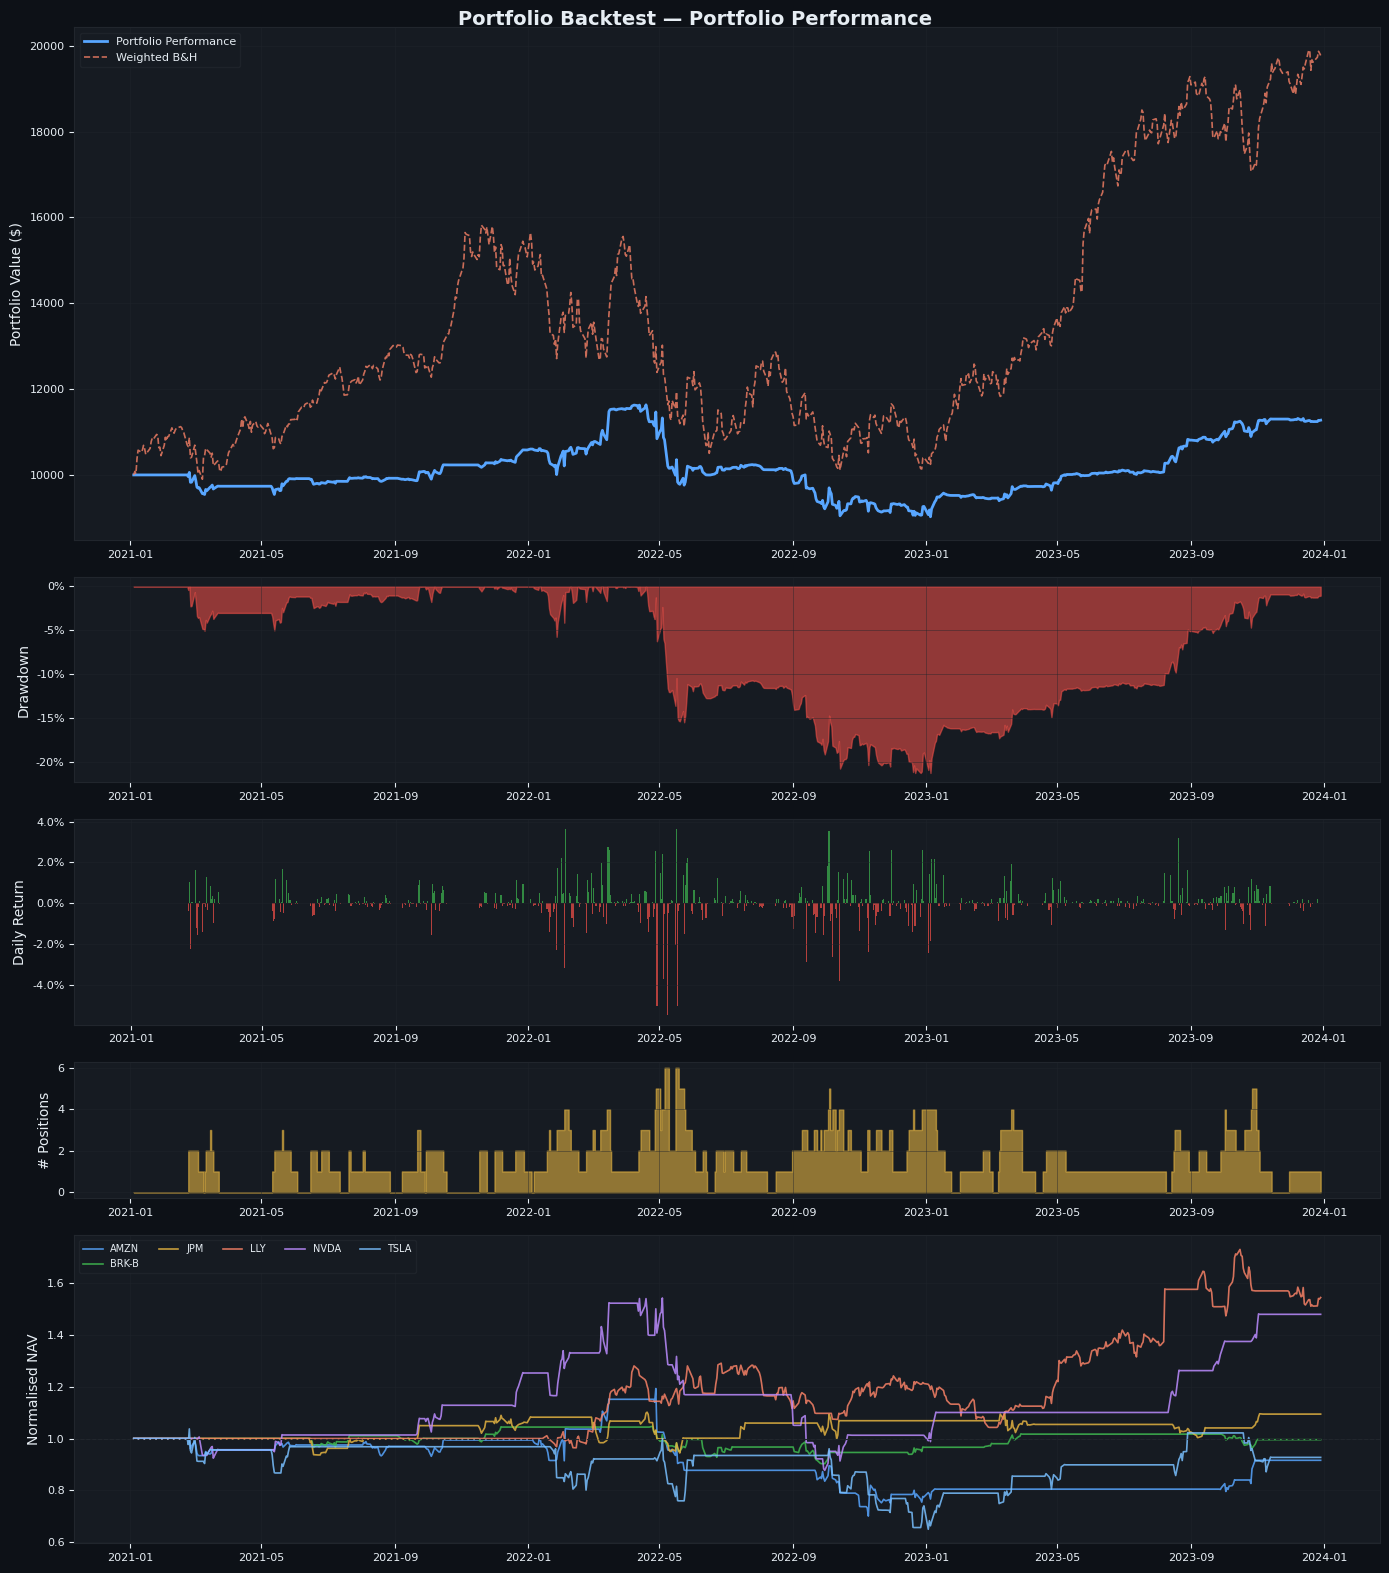

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# 8. MAIN
# ─────────────────────────────────────────────────────────────────────────────

def main():
    """
    End-to-end demo of the full framework.

    Workflow:
        1.  Load prices.
        2.  Run regime_report() — read p_trend / p_revert to guide strategy
            choice per stock.
        3.  Build signals from STOCK_CONFIG via a for loop.  Every stock's
            signal_list, signal parameters, stop function, and stop parameters
            are specified in one place, making parameter search straightforward:
            just edit the dicts in STOCK_CONFIG and re-run.
        4.  Run the weighted portfolio backtest.
        5.  Print the performance report.
        6.  Print the 1-day forecast.
        7.  Plot the five-panel dashboard.

    STOCK_CONFIG layout
    ───────────────────
    Each entry is a dict with four keys:

        signal_list    List of signal specifications for signal_combined().
                       Each element is either:
                         • a bare callable  (uses default parameters), or
                         • a (callable, kwargs_dict) tuple  (custom parameters).
                       This is the main place to tune signal parameters for
                       a parameter search.

        vote_threshold Minimum number of signals that must agree to be
                       IN market.

        stop_fn        Loss-stop function: apply_trailing_stop (dynamic) or
                       apply_static_stop (fixed at entry price).

        stop_params    Dict of keyword arguments forwarded to stop_fn.
    """
    # ── Settings ──────────────────────────────────────────────────────────
    TICKERS = ["NVDA", "AMZN", "TSLA", "BRK-B", "JPM", "LLY"]
    START   = "2021-01-01"
    END     = "2023-12-31"
    # END = None # Till today if None
    WEIGHTS = {"NVDA": 0.20, "AMZN": 0.20, "TSLA": 0.20,
               "BRK-B": 0.20, "JPM": 0.10, "LLY": 0.10}

    # ── Per-stock strategy configuration ──────────────────────────────────
    # Edit signal parameters here to run a parameter search.
    # Regime rationale is noted in comments; run regime_report() to refresh.
    STOCK_CONFIG = {
        # NVDA — high-momentum growth; wide trailing stop to ride big moves
        "NVDA": {
            "signal_list": [
                (signal_rsi,                   {"window": 14, "oversold": 35, "overbought": 75}),
                (signal_bollinger_reversion,   {"window": 20, "n_std": 2.0}),
            ],
            "vote_threshold": 2,
            "stop_fn":        apply_static_stop,
            "stop_params":    {"stop_pct": 0.06, "cooldown": 3},
        },
        # AMZN — trend follower with drawdown guard as secondary risk filter
        "AMZN": {
            "signal_list": [
                (signal_rsi,                   {"window": 14, "oversold": 35, "overbought": 75}),
                (signal_bollinger_reversion,   {"window": 20, "n_std": 2.0}),
            ],
            "vote_threshold": 2,
            "stop_fn":        apply_static_stop,
            "stop_params":    {"stop_pct": 0.06, "cooldown": 3},
        },
        # TSLA — volatile mean-reverter; static stop caps loss per entry
        "TSLA": {
            "signal_list": [
                (signal_rsi,                   {"window": 14, "oversold": 35, "overbought": 75}),
                (signal_bollinger_reversion,   {"window": 20, "n_std": 2.0}),
            ],
            "vote_threshold": 2,
            "stop_fn":        apply_static_stop,
            "stop_params":    {"stop_pct": 0.07, "cooldown": 3},
        },
        # BRK-B — slow, steady compounder; single conservative trend signal
        "BRK-B": {
            "signal_list": [
                (signal_rsi,                   {"window": 14, "oversold": 35, "overbought": 75}),
                (signal_bollinger_reversion,   {"window": 20, "n_std": 2.0}),
            ],
            "vote_threshold": 2,
            "stop_fn":        apply_static_stop,
            "stop_params":    {"stop_pct": 0.06, "cooldown": 3},
        },
        # JPM — cyclical financials; RSI oscillator + vol regime filter
        "JPM": {
            "signal_list": [
                (signal_rsi,                   {"window": 14, "oversold": 35, "overbought": 75}),
                (signal_bollinger_reversion,   {"window": 20, "n_std": 2.0}),
            ],
            "vote_threshold": 2,
            "stop_fn":        apply_static_stop,
            "stop_params":    {"stop_pct": 0.06, "cooldown": 3},
        },
        # LLY — secular growth trend (GLP-1 tailwind); trend + vol filter
        "LLY": {
            "signal_list": [
                (signal_sma_crossover,     {"fast": 50, "slow": 200}),
                (signal_volatility_regime, {"threshold": 1.3}),
            ],
            "vote_threshold": 2,
            "stop_fn":        apply_trailing_stop,
            "stop_params":    {"trail_pct": 0.08, "cooldown": 5},
        },
    }

    # ── Step 1: Load prices ───────────────────────────────────────────────
    print("\n[Step 1] Loading prices...\n")
    prices = load_prices(TICKERS, START, END)

    # ── Step 2: Regime report (first output — guides strategy choice) ──────
    print("\n[Step 2] Regime report — use p_trend / p_revert to validate strategy choices:")
    regime_report(prices)

    # ── Step 3: Build signals via for loop over STOCK_CONFIG ───────────────
    print("[Step 3] Building per-stock signals from STOCK_CONFIG...\n")
    signals = {}
    for ticker, cfg in STOCK_CONFIG.items():
        if ticker not in prices.columns:
            continue
        p   = prices[ticker].dropna()
        raw = signal_combined(
            p,
            signal_list    = cfg["signal_list"],
            vote_threshold = cfg["vote_threshold"],
        )
        signals[ticker] = cfg["stop_fn"](p, raw, **cfg["stop_params"])

    # ── Step 4: Run backtest ──────────────────────────────────────────────
    print("[Step 4] Running weighted portfolio backtest...\n")
    result = backtest_portfolio(
        prices,
        signals,
        weights         = WEIGHTS,
        initial_capital = 10000,
        commission_pct  = 0.0001,    # 0.01% per side
        slippage_pct    = 0.0005,   # 0.05% per side
    )

    # ── Step 5: Performance report ────────────────────────────────────────
    print("[Step 5] Performance report:")
    performance(result, prices, weights=WEIGHTS)

    # ── Step 6: 1-day forecast ────────────────────────────────────────────
    # Set current_positions to your actual holdings (1 = long, 0 = flat)
    print("[Step 6] One day forecast:")
    current_positions = {t: random.randint(0, 1) for t in prices.columns}
    one_day_forecast(prices, signals, weights=WEIGHTS, initial_capital = 10000,
                     current_positions=current_positions)

    # ── Step 7: Plot ──────────────────────────────────────────────────────
    plot(result, strategy_name="Portfolio Performance")


if __name__ == "__main__":
    main()


[Step 1] Loading prices...

[load_prices] Loaded 1 tickers × 4278 days.

[Step 2] Regime report — use p_trend / p_revert to validate strategy choices:

════════════════════════════════════════════════════════════════════════
  REGIME PROBABILITY REPORT
════════════════════════════════════════════════════════════════════════
  Ticker    p_trend  p_revert       Label      hurst    sma_sep   autocorr  vol_ratio
  ──────────────────────────────────────────────────────────────────────
  JPM         25.0%     75.0%   Reverting          r          t          r          r
════════════════════════════════════════════════════════════════════════

[Step 3] Building per-stock signals from STOCK_CONFIG...

[Step 4] Running weighted portfolio backtest...

[Step 5] Performance report:

════════════════════════════════════════════════════════════
  PORTFOLIO PERFORMANCE REPORT
════════════════════════════════════════════════════════════
  Metric                           Strategy     Benchmark
  ────

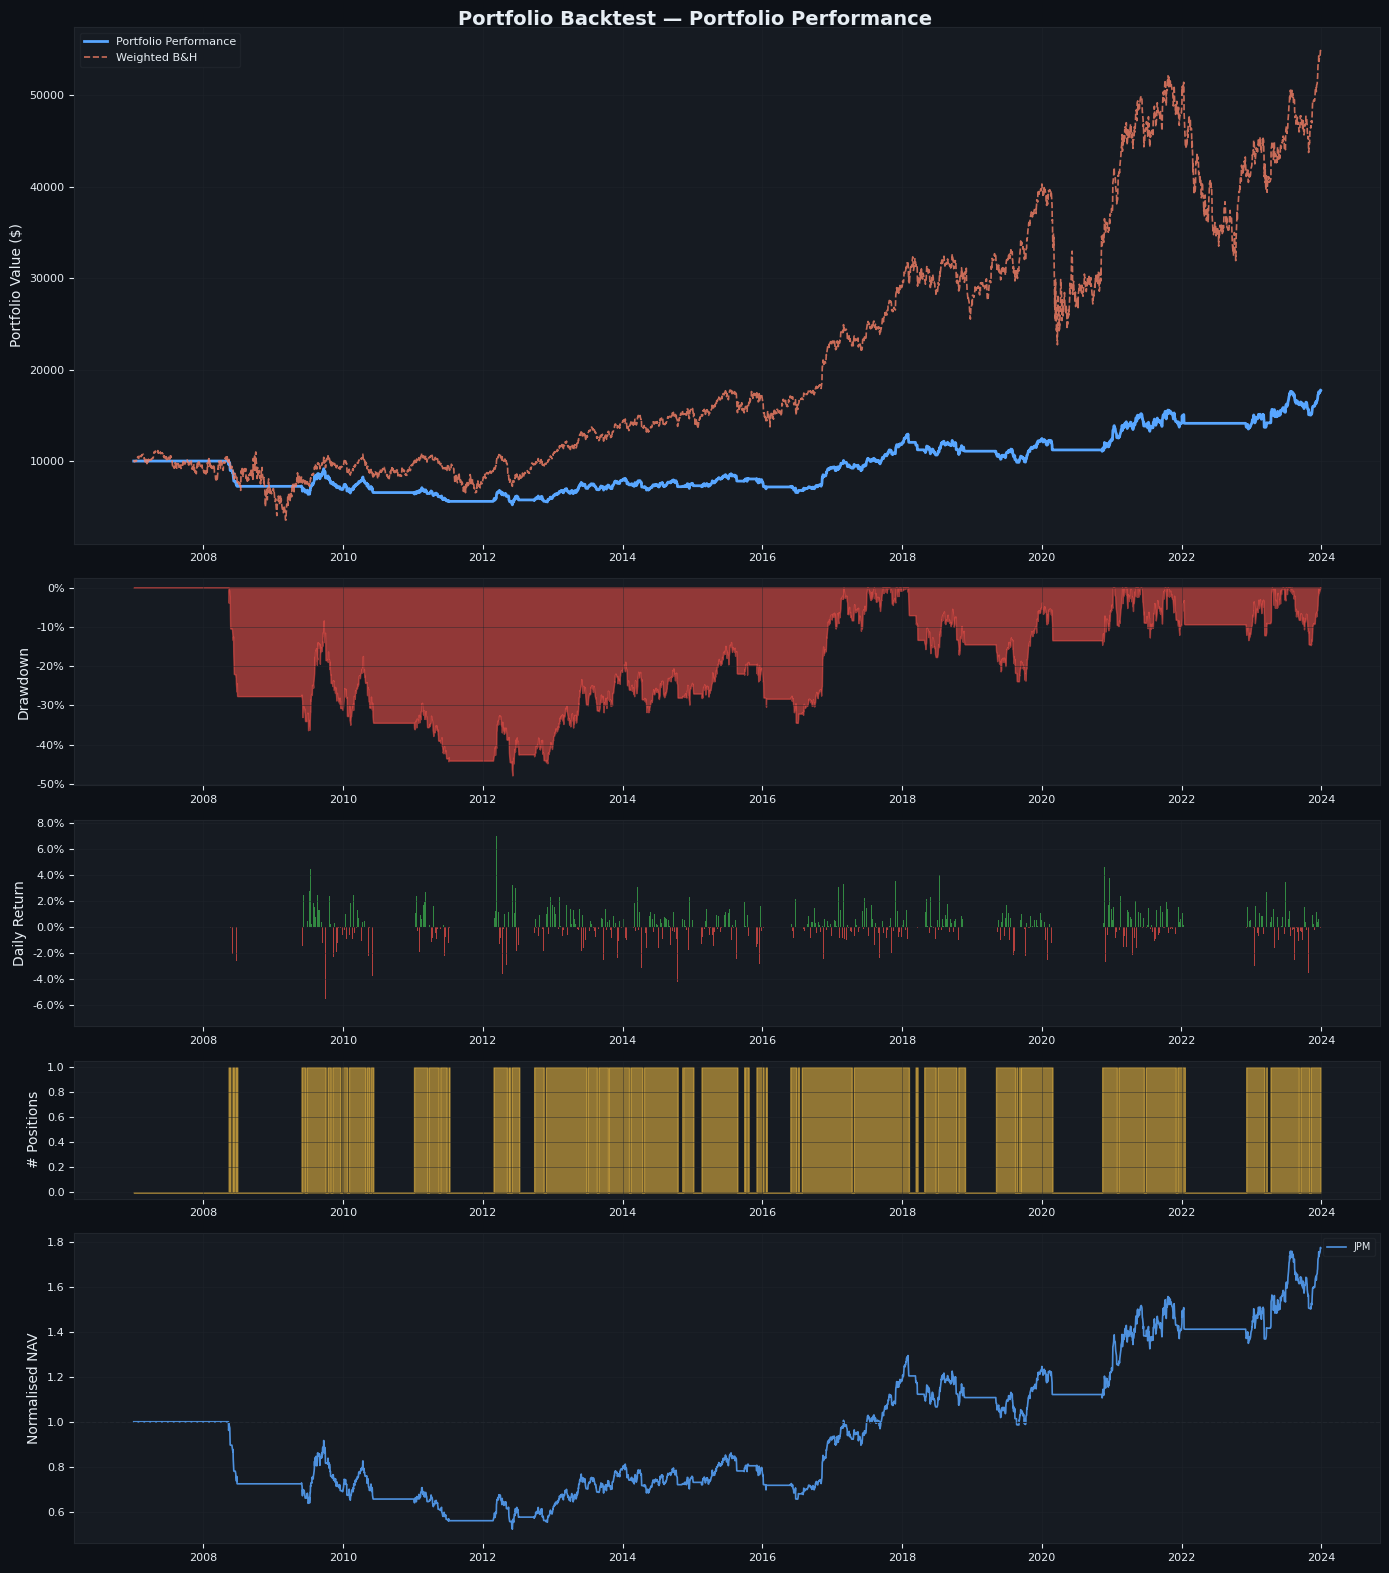

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# 9. SINGLE STOCK EXAMPLE
# ─────────────────────────────────────────────────────────────────────────────

def main():
    # ── Settings ──────────────────────────────────────────────────────────
    TICKERS = ["JPM",]
    START   = "2007-01-01"
    END     = "2023-12-31"
    # END = "" # Till today
    WEIGHTS = {"JPM": 1.,}

    # ── Per-stock strategy configuration ──────────────────────────────────
    # Edit signal parameters here to run a parameter search.
    # Regime rationale is noted in comments; run regime_report() to refresh.
    STOCK_CONFIG = {
        # JPM — cyclical financials; RSI oscillator + vol regime filter
        "JPM": {
            "signal_list": [
                (signal_sma_crossover,     {"fast": 50, "slow": 200}),
                (signal_volatility_regime, {"threshold": 1.3}),
            ],
            "vote_threshold": 2,
            "stop_fn":        apply_trailing_stop,
            "stop_params":    {"trail_pct": 0.08, "cooldown": 5},
        },
    }

    # ── Step 1: Load prices ───────────────────────────────────────────────
    print("\n[Step 1] Loading prices...\n")
    prices = load_prices(TICKERS, START, END)

    # ── Step 2: Regime report (first output — guides strategy choice) ──────
    print("\n[Step 2] Regime report — use p_trend / p_revert to validate strategy choices:")
    regime_report(prices)

    # ── Step 3: Build signals via for loop over STOCK_CONFIG ───────────────
    print("[Step 3] Building per-stock signals from STOCK_CONFIG...\n")
    signals = {}
    for ticker, cfg in STOCK_CONFIG.items():
        if ticker not in prices.columns:
            continue
        p   = prices[ticker].dropna()
        raw = signal_combined(
            p,
            signal_list    = cfg["signal_list"],
            vote_threshold = cfg["vote_threshold"],
        )
        signals[ticker] = cfg["stop_fn"](p, raw, **cfg["stop_params"])

    # ── Step 4: Run backtest ──────────────────────────────────────────────
    print("[Step 4] Running weighted portfolio backtest...\n")
    result = backtest_portfolio(
        prices,
        signals,
        weights         = WEIGHTS,
        initial_capital = 10000,
        commission_pct  = 0.0001,    # 0.01% per side
        slippage_pct    = 0.0005,   # 0.05% per side
    )

    # ── Step 5: Performance report ────────────────────────────────────────
    print("[Step 5] Performance report:")
    performance(result, prices, weights=WEIGHTS)

    # ── Step 6: 1-day forecast ────────────────────────────────────────────
    # Set current_positions to your actual holdings (1 = long, 0 = flat)
    print("[Step 6] One day forecast:")
    current_positions = {t: random.randint(0, 1) for t in prices.columns}
    one_day_forecast(prices, signals, weights=WEIGHTS, initial_capital = 10000,
                     current_positions=current_positions)

    # ── Step 7: Plot ──────────────────────────────────────────────────────
    plot(result, strategy_name="Portfolio Performance")


if __name__ == "__main__":
    main()


[Step 1] Loading prices...
[load_prices] Loaded 1 tickers × 4227 days.

[Step 2] Regime report:

════════════════════════════════════════════════════════════════════════
  REGIME PROBABILITY REPORT
════════════════════════════════════════════════════════════════════════
  Ticker    p_trend  p_revert       Label      hurst    sma_sep   autocorr  vol_ratio
  ──────────────────────────────────────────────────────────────────────
  IBIT        25.0%     75.0%   Reverting          r          r          t          r
════════════════════════════════════════════════════════════════════════

[Step 3] Grid search — optimising signal parameters on train window...

────────────────────────────────────────────────────────────
  GRID SEARCH  —  IBIT  |  train window: 2014-09-30 → 2024-01-01
  1 valid combinations to evaluate
────────────────────────────────────────────────────────────

  Best params (train Sharpe = 1.044):
    window       = 40
    n_std        = 2.0
    bw_window    = 50
    bw_qu

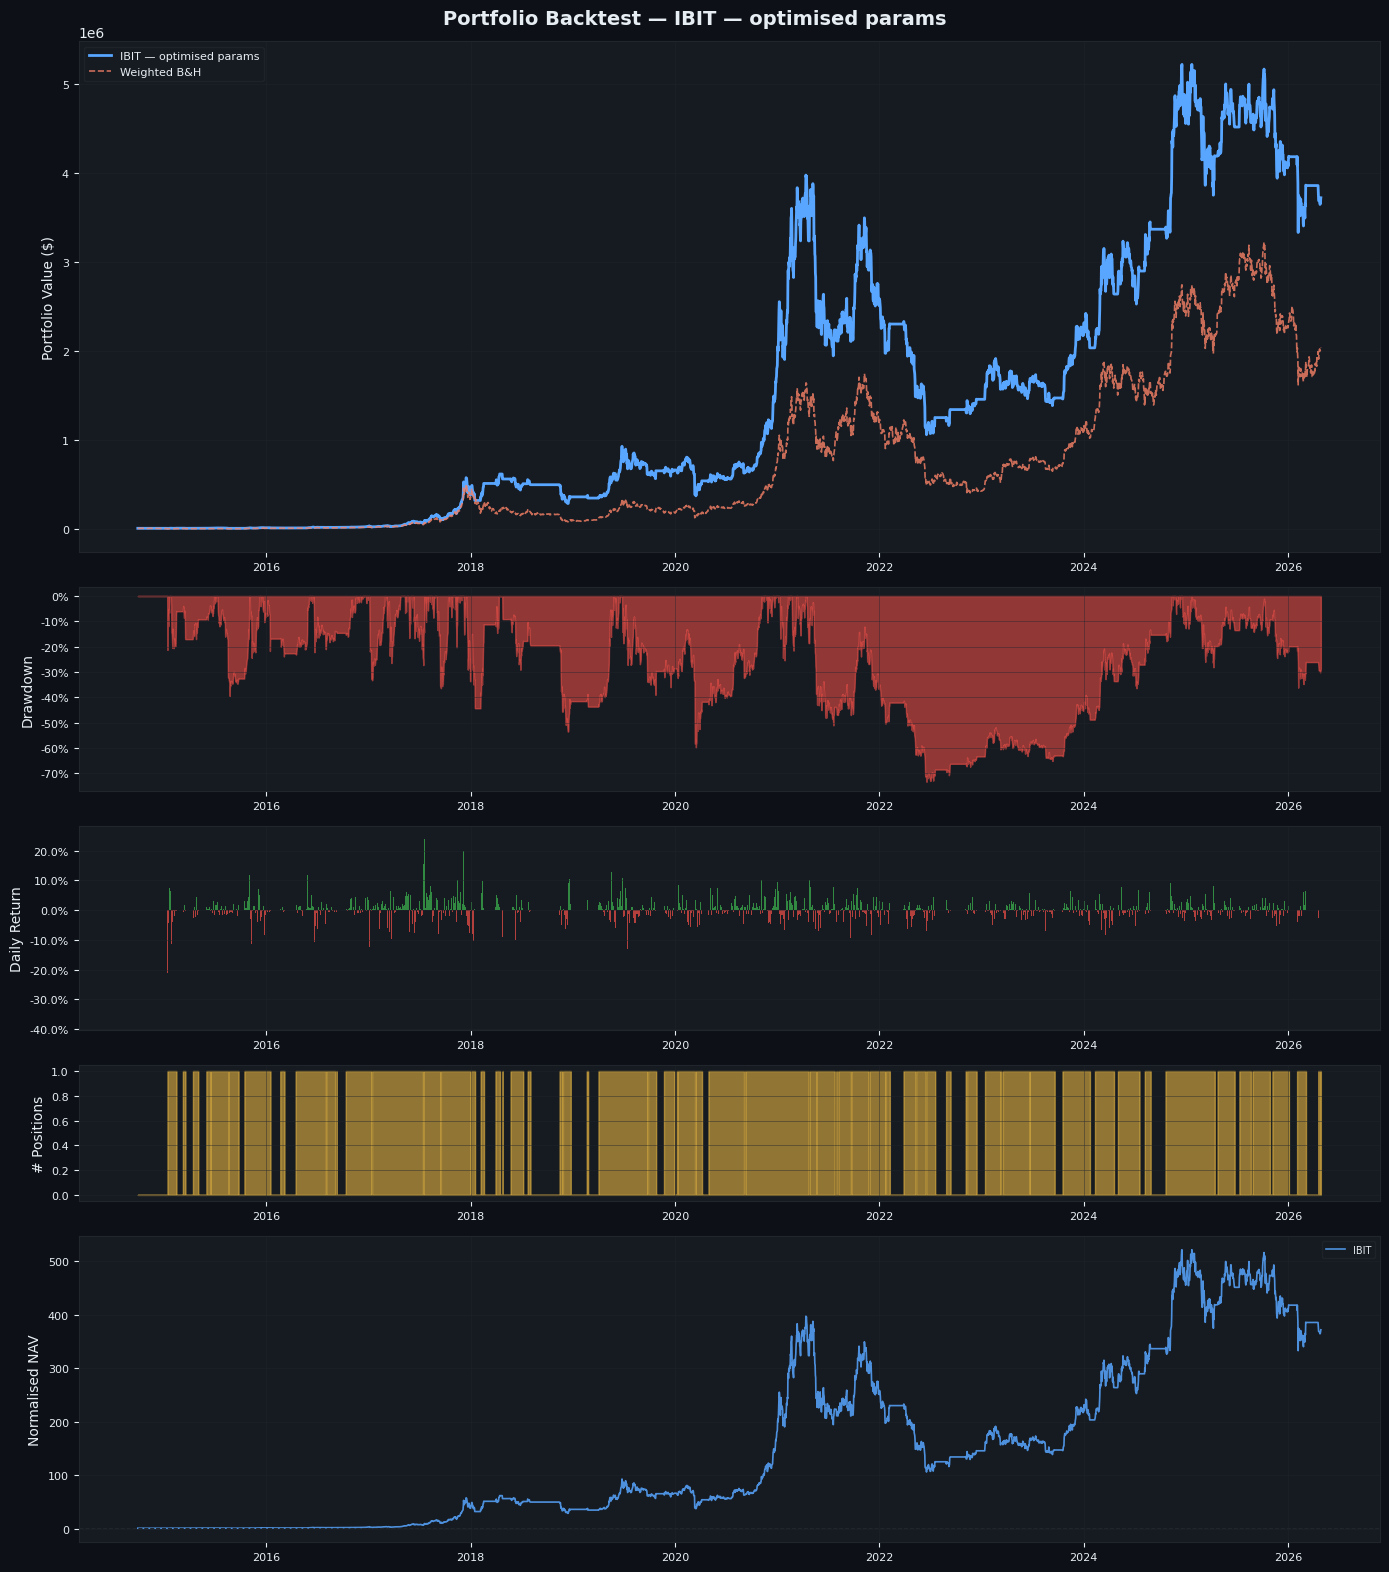

In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# 10. OPTIMIZING IBIT signal_bollinger_adaptive EXAMPLE
# ─────────────────────────────────────────────────────────────────────────────
#
# OPTIMISATION APPROACH
# ─────────────────────
# A walk-forward grid search is used instead of a simple in-sample grid search.
# The full date range is split into:
#   • Train window  — the model sees this to score each parameter combination.
#   • Test window   — the winning combo is evaluated here (out-of-sample).
#
# This prevents the most common backtest pitfall: picking parameters that
# perfectly fit the past but fail on new data.
#
# The objective metric is the Sharpe ratio on the TRAIN window.
# You can swap it for Calmar, Sortino, or total return — see _score().
#
# HOW TO EXTEND
# ─────────────
# • Add more keys to PARAM_GRID to search additional parameters
#   (e.g. trail_pct, threshold).
# • Change TRAIN_END / TEST_START to adjust the split point.
# • Set N_JOBS > 1 to parallelise the grid search (requires joblib).
# ─────────────────────────────────────────────────────────────────────────────

from __future__ import annotations

import itertools
from typing import Any, Dict, List, Optional, Tuple


# ─────────────────────────────────────────────────────────────────────────────
# HELPERS
# ─────────────────────────────────────────────────────────────────────────────

def _build_signal(
    prices:    pd.Series,
    trail_pct: float,
    cooldown:  int,
    window:    int,
    n_std:     float,
    bw_window: int,
    bw_quantile:float,
) -> pd.Series:
    raw = signal_combined(
        prices,
        signal_list=[
            (signal_bollinger_adaptive_ibit, {
                "window":    window,
                "n_std":     n_std,
                "bw_window": bw_window,
                "bw_quantile": bw_quantile,
            }),
        ],
        vote_threshold=1,
    )
    return apply_trailing_stop(prices, raw, trail_pct=trail_pct, cooldown=cooldown)


def _score(prices: pd.DataFrame, signals: Dict[str, pd.Series],
           weights: Dict[str, float], capital: float = 10000) -> float:
    """
    Run a backtest on the given price window and return the Sharpe ratio.
    Returns -inf if the backtest produces no valid trades.

    Swap the return value to optimise for a different metric:
        calmar  →  result["portfolio"]["strategy_ret"].pipe(_calmar)
        sortino →  ...
        total return → result["portfolio"]["nav"].iloc[-1] / capital - 1
    """
    result = backtest_portfolio(
        prices, signals, weights=weights,
        initial_capital=capital, commission_pct=0.0001, slippage_pct=0.0005,
    )
    rets = result["portfolio"]["strategy_ret"]
    std  = rets.std()
    if std == 0 or np.isnan(std):
        return -np.inf
    return (rets.mean() / std) * np.sqrt(252) # annualised Sharpe


def _expand_grid(grid: Dict[str, List[Any]]) -> List[Dict[str, Any]]:
    """Return all combinations of the parameter grid as a list of dicts."""
    keys   = list(grid.keys())
    combos = list(itertools.product(*grid.values()))
    return [dict(zip(keys, c)) for c in combos]


def _valid_combo(params: Dict[str, Any]) -> bool:
    """Filter out parameter combinations that are structurally invalid."""
    # return params["fast"] < params["slow"]
    return True


def grid_search(
    prices:      pd.DataFrame,
    ticker:      str,
    weights:     Dict[str, float],
    param_grid:  Dict[str, List[Any]],
    train_start: str,
    train_end:   str,
    capital:     float = 10000,
) -> Tuple[Dict[str, Any], pd.DataFrame]:
    """
    Exhaustive grid search over ``param_grid`` on the TRAIN window.

    Args:
        prices:     Full price DataFrame (train + test combined).
        ticker:     Ticker to optimise (must be a column in ``prices``).
        weights:    Portfolio weights dict  e.g. ``{"JPM": 1.0}``.
        param_grid: Dict of param name → list of candidate values.
        train_end:  Exclusive end date of the training window (``"YYYY-MM-DD"``).
        capital:    Nominal capital for scoring (default 10,000).

    Returns:
        best_params — dict of the winning parameter combination.
        results_df  — DataFrame with all combos ranked by train Sharpe.
    """
    train_prices = prices[train_start:train_end]
    p_series     = train_prices[ticker].dropna()

    all_combos = [c for c in _expand_grid(param_grid) if _valid_combo(c)]
    print(f"\n{'─' * 60}")
    print(f"  GRID SEARCH  —  {ticker}  |  train window: {train_prices.index[0].date()} "
          f"→ {train_prices.index[-1].date()}")
    print(f"  {len(all_combos)} valid combinations to evaluate")
    print(f"{'─' * 60}")

    rows = []
    for params in all_combos:
        sig    = _build_signal(p_series, **params)
        sharpe = _score(train_prices, {ticker: sig}, weights, capital)
        rows.append({**params, "train_sharpe": round(sharpe, 4)})

    results_df  = pd.DataFrame(rows).sort_values("train_sharpe", ascending=False)
    best_params = results_df.iloc[0].drop("train_sharpe").to_dict()
    for k, v in best_params.items():
        if isinstance(param_grid[k][0], int):
            best_params[k] = int(v)

    print(f"\n  Best params (train Sharpe = {results_df['train_sharpe'].iloc[0]:.3f}):")
    for k, v in best_params.items():
        print(f"    {k:<12} = {v}")
    print(f"{'─' * 60}\n")
    return best_params, results_df

def signal_bollinger_adaptive_ibit(
    prices: pd.Series,
    window: int = 20,
    n_std: float = 2.0,
    bw_window: int = 50,
    bw_quantile: float = 0.5,
) -> pd.Series:
    """
    Adaptive Bollinger Band strategy based on bandwidth regime.

    Combines trend-following and mean-reversion behaviour depending on
    the current volatility regime as measured by Bollinger Bandwidth.

    Regime logic:
        - LOW bandwidth (below quantile)  → TREND mode
        - HIGH bandwidth (above quantile) → MEAN-REVERSION mode

    Strategy rules:
        TREND mode:
            - IN (1) when price breaks above upper band
            - OUT (0) when price falls below middle band

        REVERSION mode:
            - IN (1) when price touches lower band
            - OUT (0) when price crosses above middle band

    Args:
        prices:        Daily close price series.
        window:        Rolling window for Bollinger Bands (default 20).
        n_std:         Band width in standard deviations (default 2.0).
        bw_window:     Lookback window for bandwidth distribution (default 50).
        bw_quantile:   Quantile threshold for regime split (0–1, default 0.5).

    Returns:
        pd.Series: Binary signal (0/1) named "BollingerAdaptive".

    Notes:
        - Stateful signal: holds position between entry/exit triggers.
        - Starts OUT of market until first valid signal.
        - Uses rolling quantile → no look-ahead bias.
    """
    mid   = prices.rolling(window).mean()
    std   = prices.rolling(window).std()
    upper = mid + n_std * std
    lower = mid - n_std * std

    bandwidth = (upper - lower) / mid
    bw_thresh = bandwidth.rolling(bw_window).quantile(bw_quantile)

    ma100 = prices.rolling(100).mean().shift(1)

    pos = np.zeros(len(prices))
    in_mkt = False

    for i in range(len(prices)):
        p  = prices.iloc[i]
        m  = mid.iloc[i]
        u  = upper.iloc[i]
        l  = lower.iloc[i]
        bw = bandwidth.iloc[i]
        th = bw_thresh.iloc[i]
        ma = ma100.iloc[i]

        if np.isnan(th) or np.isnan(ma):
            pos[i] = 0
            continue

        is_trend = p > ma

        if is_trend:
            if not np.isnan(u):
                if p > u:
                    in_mkt = True
                elif p < l:
                    in_mkt = False
        else:
            if not np.isnan(l):
                if p < l:
                    in_mkt = True
                elif p > m:
                    in_mkt = False

        pos[i] = int(in_mkt)

    return pd.Series(pos, index=prices.index, name="BollingerAdaptiveIbit")

# ─────────────────────────────────────────────────────────────────────────────
# PARAMETER GRID
# Edit this dict to define the search space.
# Every key must match a keyword argument of the corresponding signal function.
# ─────────────────────────────────────────────────────────────────────────────

# PARAM_GRID: Dict[str, List[Any]] = {
#     # signal_bollinger_adaptive_ibit kwargs
#     "window":    [40, 60],
#     "n_std":     [2.0, 2.5],
#     "bw_window": [50],
#     "bw_quantile": [0.5, 0.7],
#     # apply_trailing_stop kwargs
#     "trail_pct": [0.2, 0.3],
#     "cooldown": [1],
# }

PARAM_GRID: Dict[str, List[Any]] = {
    # signal_bollinger_adaptive_ibit kwargs
    "window":    [40],
    "n_std":     [2.0],
    "bw_window": [50],
    "bw_quantile": [0.5],
    # apply_trailing_stop kwargs
    "trail_pct": [0.3],
    "cooldown": [1],
}


# ─────────────────────────────────────────────────────────────────────────────
# MAIN
# ─────────────────────────────────────────────────────────────────────────────

def main():
    # ── Settings ──────────────────────────────────────────────────────────
    TICKER = "IBIT"
    TICKERS = [TICKER]
    START   = "2014-09-30"
    # END     = "2024-12-31"
    END     = "" # Till today
    WEIGHTS = {TICKER: 1.0}
    CAPITAL = 10000
    TRAIN_START = "2014-09-30"
    TRAIN_END   = "2024-01-01"
    TEST_START  = "2024-01-01"
    TEST_END    = "2025-12-31"

    # ── Step 1: Load prices ───────────────────────────────────────────────
    print("\n[Step 1] Loading prices...")
    # prices = load_prices(TICKERS, START, END)
    # IBIT is different from normal stocks
    def load_prices_ibit(tickers: List[str], start: str, end: str) -> pd.DataFrame:
        try:
            import yfinance as yf
        except ImportError as exc:
            raise RuntimeError("yfinance is required:  pip install yfinance") from exc
        if end < "2024-01-11":
            raw = yf.download(["BTC-USD"], start=start, end=end, auto_adjust=True, progress=False)
            prices = (raw["Close"] / 46368.585938 * 26.629999 if isinstance(raw.columns, pd.MultiIndex)
                    else raw[["Close"]].rename(columns={"Close": tickers[0]}) / 46368.585938 * 26.629999)
            prices = prices.rename(columns={"BTC-USD": "IBIT"})
            prices.columns = [str(c) for c in prices.columns]
            prices = prices.ffill(limit=5)
            prices = prices.dropna(axis=1, thresh=int(len(prices) * 0.90))
        else:
            raw_btc = yf.download(["BTC-USD"], start=start, end="2024-01-11", auto_adjust=True, progress=False)
            prices_btc = (raw_btc["Close"] / 46368.585938 * 26.629999 if isinstance(raw_btc.columns, pd.MultiIndex)
                    else raw_btc[["Close"]].rename(columns={"Close": tickers[0]}) / 46368.585938 * 26.629999)
            prices_btc = prices_btc.rename(columns={"BTC-USD": "IBIT"})
            raw_ibit = yf.download(["IBIT"], start="2024-01-11", end=end, auto_adjust=True, progress=False)
            prices_ibit = (raw_ibit["Close"] if isinstance(raw_ibit.columns, pd.MultiIndex)
                    else raw_ibit[["Close"]].rename(columns={"Close": tickers[0]}))
            prices = pd.concat([prices_btc[prices_btc.index.weekday < 5], prices_ibit], axis = 0)
            prices.columns = [str(c) for c in prices.columns]
            prices = prices.ffill(limit=5)
            prices = prices.dropna(axis=1, thresh=int(len(prices) * 0.90))
        print(f"[load_prices] Loaded {len(prices.columns)} tickers × {len(prices)} days.")
        return prices

    prices = load_prices_ibit(TICKERS, START, END)

    # ── Step 2: Regime report ─────────────────────────────────────────────
    print("\n[Step 2] Regime report:")
    regime_report(prices)

    # ── Step 3: Grid search on TRAIN window ───────────────────────────────
    print("[Step 3] Grid search — optimising signal parameters on train window...")
    best_params, search_results = grid_search(
        prices      = prices,
        ticker      = TICKER,
        weights     = WEIGHTS,
        param_grid  = PARAM_GRID,
        train_start = TRAIN_START,
        train_end   = TRAIN_END,
        capital     = CAPITAL,
    )

    # Print the top-10 combos for reference
    print("  Top-10 parameter combinations (train window):")
    print(search_results.head(10).to_string(index=False))
    print()

    # ── Step 4: Evaluate best params OUT-OF-SAMPLE (test window) ──────────
    print(f"[Step 4] Out-of-sample evaluation on test window "
          f"({TEST_START} → {TEST_END})...")

    test_prices = prices[TEST_START:TEST_END]
    p_test      = test_prices[TICKER].dropna()

    best_signal_test = _build_signal(p_test, **best_params)
    test_result      = backtest_portfolio(
        test_prices,
        {TICKER: best_signal_test},
        weights         = WEIGHTS,
        initial_capital = CAPITAL,
        commission_pct  = 0.0001,
        slippage_pct    = 0.0005,
    )

    print("\n  ── Out-of-sample performance (best params from grid search) ──")
    performance(test_result, test_prices, weights=WEIGHTS)

    # ── Step 5: Refit on FULL history with best params ────────────────────
    # Now that we've validated out-of-sample, refit on the full date range
    # to produce the most up-to-date signal for the live forecast.
    print(f"\n[Step 5] Refitting on full history ({START} → {END}) "
          f"with best params for live forecast...")

    p_full       = prices[TICKER].dropna()
    best_signal_full = _build_signal(p_full, **best_params)
    signals_full     = {TICKER: best_signal_full}

    full_result = backtest_portfolio(
        prices, signals_full, weights=WEIGHTS,
        initial_capital=CAPITAL, commission_pct=0.0001, slippage_pct=0.0005,
    )

    print("\n  ── Full-period performance (best params) ──")
    performance(full_result, prices, weights=WEIGHTS)

    # ── Step 6: 1-day forecast ────────────────────────────────────────────
    print("\n[Step 6] One-day forecast (signal from best params, full history refit):")
    current_positions = {TICKER: 0}   # set to your actual holdings
    one_day_forecast(
        prices, signals_full,
        weights            = WEIGHTS,
        initial_capital    = CAPITAL,
        current_positions  = current_positions,
    )

    # ── Step 7: Plot full-period backtest ─────────────────────────────────
    plot(full_result, strategy_name=f"{TICKER} — optimised params")


if __name__ == "__main__":
    main()


[Step 1] Loading prices...
[load_prices] Loaded 1 tickers × 4227 days.

[Step 2] Regime report:

════════════════════════════════════════════════════════════════════════
  REGIME PROBABILITY REPORT
════════════════════════════════════════════════════════════════════════
  Ticker    p_trend  p_revert       Label      hurst    sma_sep   autocorr  vol_ratio
  ──────────────────────────────────────────────────────────────────────
  IBIT        25.0%     75.0%   Reverting          r          r          t          r
════════════════════════════════════════════════════════════════════════

[Step 3] Grid search — optimising signal parameters on train window...

────────────────────────────────────────────────────────────
  GRID SEARCH  —  IBIT  |  train window: 2014-09-30 → 2024-01-01
  1 valid combinations to evaluate
────────────────────────────────────────────────────────────

  Best params (train Sharpe = 1.219):
    fast         = 20
    slow         = 150
    trend_window = 50
    buffe

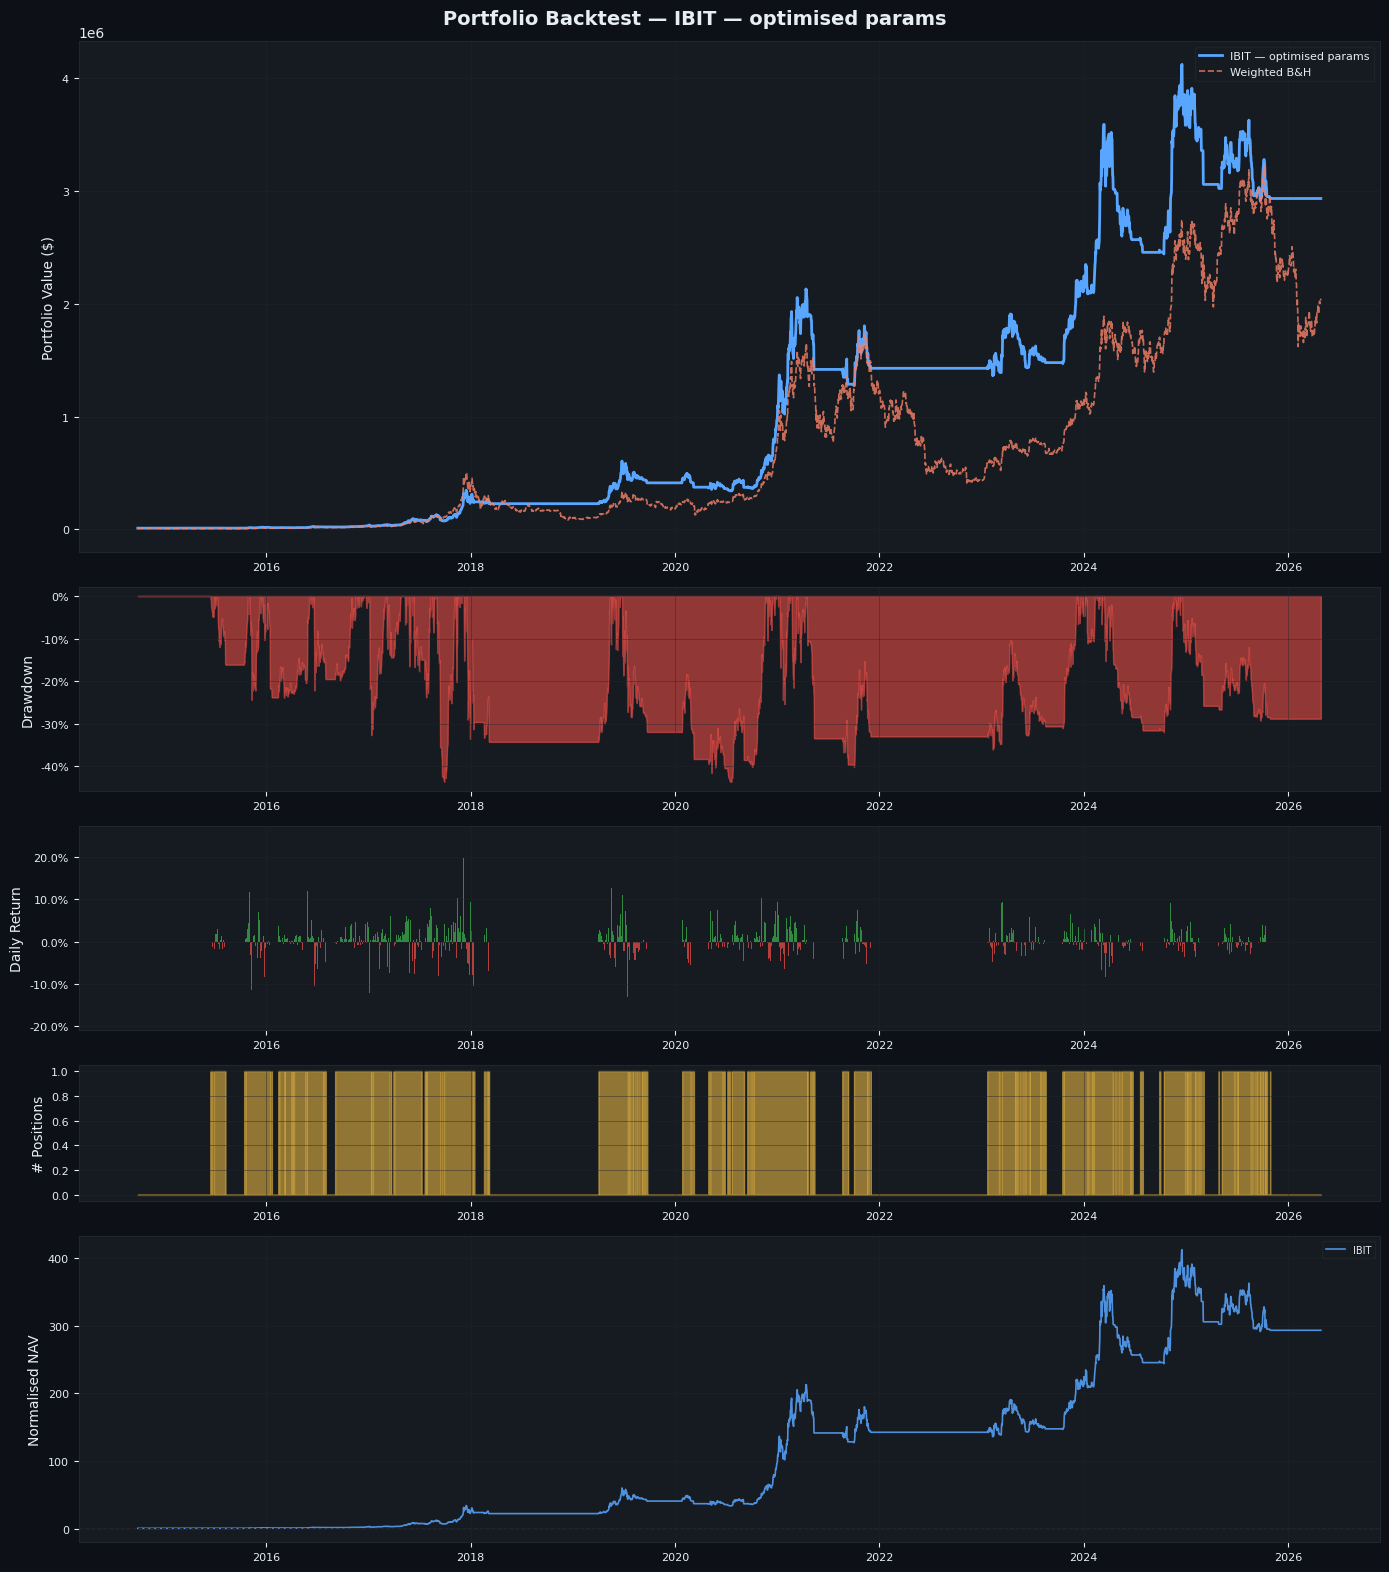

In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# 11. OPTIMIZING IBIT signal_sma_crossover_ibit EXAMPLE
# ─────────────────────────────────────────────────────────────────────────────
#
# OPTIMISATION APPROACH
# ─────────────────────
# A walk-forward grid search is used instead of a simple in-sample grid search.
# The full date range is split into:
#   • Train window  — the model sees this to score each parameter combination.
#   • Test window   — the winning combo is evaluated here (out-of-sample).
#
# This prevents the most common backtest pitfall: picking parameters that
# perfectly fit the past but fail on new data.
#
# The objective metric is the Sharpe ratio on the TRAIN window.
# You can swap it for Calmar, Sortino, or total return — see _score().
#
# HOW TO EXTEND
# ─────────────
# • Add more keys to PARAM_GRID to search additional parameters
#   (e.g. trail_pct, threshold).
# • Change TRAIN_END / TEST_START to adjust the split point.
# • Set N_JOBS > 1 to parallelise the grid search (requires joblib).
# ─────────────────────────────────────────────────────────────────────────────

from __future__ import annotations

import itertools
from typing import Any, Dict, List, Optional, Tuple


# ─────────────────────────────────────────────────────────────────────────────
# HELPERS
# ─────────────────────────────────────────────────────────────────────────────

def _build_signal(
    prices:             pd.Series,
    trail_pct:          float,
    cooldown:           int,
    fast:               int,
    slow:               int,
    trend_window:       int,
    buffer:             float,
    slope_window:       int,
    slope_threshold:    float,
    reentry_buffer:     float,
    reentry_lookback:   int,
) -> pd.Series:
    raw = signal_combined(
        prices,
        signal_list=[
            (signal_sma_crossover_ibit, {
                "fast":             fast,
                "slow":             slow,
                "trend_window":     trend_window,
                "buffer":           buffer,
                "slope_window":     slope_window,
                "slope_threshold":  slope_threshold,
                "reentry_buffer":   reentry_buffer,
                "reentry_lookback": reentry_lookback,
            }),
        ],
        vote_threshold=1,
    )
    return apply_trailing_stop(prices, raw, trail_pct=trail_pct, cooldown=cooldown)


def _score(prices: pd.DataFrame, signals: Dict[str, pd.Series],
           weights: Dict[str, float], capital: float = 10000) -> float:
    """
    Run a backtest on the given price window and return the Sharpe ratio.
    Returns -inf if the backtest produces no valid trades.

    Swap the return value to optimise for a different metric:
        calmar  →  result["portfolio"]["strategy_ret"].pipe(_calmar)
        sortino →  ...
        total return → result["portfolio"]["nav"].iloc[-1] / capital - 1
    """
    result = backtest_portfolio(
        prices, signals, weights=weights,
        initial_capital=capital, commission_pct=0.0001, slippage_pct=0.0005,
    )
    rets = result["portfolio"]["strategy_ret"]
    std  = rets.std()
    if std == 0 or np.isnan(std):
        return -np.inf
    return (rets.mean() / std) * np.sqrt(252) # annualised Sharpe


def _expand_grid(grid: Dict[str, List[Any]]) -> List[Dict[str, Any]]:
    """Return all combinations of the parameter grid as a list of dicts."""
    keys   = list(grid.keys())
    combos = list(itertools.product(*grid.values()))
    return [dict(zip(keys, c)) for c in combos]


def _valid_combo(params: Dict[str, Any]) -> bool:
    """Filter out parameter combinations that are structurally invalid."""
    return params["fast"] < params["slow"]
    # return True


def grid_search(
    prices:      pd.DataFrame,
    ticker:      str,
    weights:     Dict[str, float],
    param_grid:  Dict[str, List[Any]],
    train_start: str,
    train_end:   str,
    capital:     float = 10000,
) -> Tuple[Dict[str, Any], pd.DataFrame]:
    """
    Exhaustive grid search over ``param_grid`` on the TRAIN window.

    Args:
        prices:     Full price DataFrame (train + test combined).
        ticker:     Ticker to optimise (must be a column in ``prices``).
        weights:    Portfolio weights dict  e.g. ``{"JPM": 1.0}``.
        param_grid: Dict of param name → list of candidate values.
        train_end:  Exclusive end date of the training window (``"YYYY-MM-DD"``).
        capital:    Nominal capital for scoring (default 10,000).

    Returns:
        best_params — dict of the winning parameter combination.
        results_df  — DataFrame with all combos ranked by train Sharpe.
    """
    train_prices = prices[train_start:train_end]
    p_series     = train_prices[ticker].dropna()

    all_combos = [c for c in _expand_grid(param_grid) if _valid_combo(c)]
    print(f"\n{'─' * 60}")
    print(f"  GRID SEARCH  —  {ticker}  |  train window: {train_prices.index[0].date()} "
          f"→ {train_prices.index[-1].date()}")
    print(f"  {len(all_combos)} valid combinations to evaluate")
    print(f"{'─' * 60}")

    rows = []
    for params in all_combos:
        sig    = _build_signal(p_series, **params)
        sharpe = _score(train_prices, {ticker: sig}, weights, capital)
        rows.append({**params, "train_sharpe": round(sharpe, 4)})

    results_df  = pd.DataFrame(rows).sort_values("train_sharpe", ascending=False)
    best_params = results_df.iloc[0].drop("train_sharpe").to_dict()
    for k, v in best_params.items():
        if isinstance(param_grid[k][0], int):
            best_params[k] = int(v)

    print(f"\n  Best params (train Sharpe = {results_df['train_sharpe'].iloc[0]:.3f}):")
    for k, v in best_params.items():
        print(f"    {k:<12} = {v}")
    print(f"{'─' * 60}\n")
    return best_params, results_df


def signal_sma_crossover_ibit(
    prices: pd.Series,
    fast: int = 50,
    slow: int = 200,
    trend_window: int = 100,
    buffer: float = 0.01,
    slope_window: int = 5,
    slope_threshold: float = 0.0,
    reentry_buffer: float = 0.05,
    reentry_lookback: int = 20,
) -> pd.Series:
    """
    SMA crossover strategy with buffer, slope filter, macro trend filter,
    and explicit re-entry logic.

    Enhancements:
        (1) Buffer reduces whipsaw near crossover
        (2) Slow SMA slope confirms momentum
        (3) Macro trend filter (price vs long SMA)
        (4) Fast re-entry after pullbacks

    Signal logic:

        ENTER (1) when ANY of:
            - fast > slow * (1 + buffer) AND slope > threshold AND price > trend_sma
            - price > slow * (1 + buffer) AND slope > threshold AND price > trend_sma   (early entry)
            - fast > slow AND price near recent high AND price > trend_sma              (re-entry)

        EXIT (0) when:
            - fast < slow * (1 - buffer)
            OR price < trend_sma

    Args:
        prices:          Price series
        fast:            Fast SMA window
        slow:            Slow SMA window
        trend_window:    Macro trend filter window
        buffer:          Separation buffer for crossover confirmation
        slope_window:    Window for slope estimation
        slope_threshold: Minimum slope for trend confirmation
        reentry_buffer:  % distance from recent high for re-entry
        reentry_lookback:Lookback window for recent high

    Returns:
        pd.Series: Binary position signal (0/1)
    """

    fast_sma = prices.rolling(fast).mean()
    slow_sma = prices.rolling(slow).mean()
    trend_sma = prices.rolling(trend_window).mean()

    slow_slope = slow_sma.diff(slope_window)
    recent_high = prices.rolling(reentry_lookback).max()

    pos = np.zeros(len(prices))
    in_mkt = False

    for i in range(len(prices)):
        f = fast_sma.iloc[i]
        s = slow_sma.iloc[i]
        t = trend_sma.iloc[i]
        slope = slow_slope.iloc[i]
        p = prices.iloc[i]
        rh = recent_high.iloc[i]

        # skip until all signals available
        if np.isnan(f) or np.isnan(s) or np.isnan(t) or np.isnan(slope) or np.isnan(rh):
            pos[i] = 0
            continue

        # =========================
        # ENTRY / RE-ENTRY
        # =========================
        if not in_mkt:

            # main entry
            cond_trend = (f > s * (1 + buffer)) and (slope > slope_threshold)

            # early entry (price leads MA)
            cond_early = (p > s * (1 + buffer)) and (slope > slope_threshold)

            # re-entry (strong momentum near highs)
            cond_reentry = (f > s) and (p > f) and (p > (1 - reentry_buffer) * rh)

            if (cond_trend or cond_early or cond_reentry) and (p > 0.95 * t):
                in_mkt = True

        # =========================
        # EXIT
        # =========================
        else:
            if (f < s * (1 - buffer)) or (p < t):
                in_mkt = False

        pos[i] = int(in_mkt)

    return pd.Series(pos, index=prices.index, name="SMA_Crossover_Ibit")

# ─────────────────────────────────────────────────────────────────────────────
# PARAMETER GRID
# Edit this dict to define the search space.
# Every key must match a keyword argument of the corresponding signal function.
# ─────────────────────────────────────────────────────────────────────────────

PARAM_GRID: Dict[str, List[Any]] = {
    # signal_sma_crossover_ibit kwargs
    "fast": [20],
    "slow": [150],
    "trend_window": [50],
    "buffer": [0.01],
    "slope_window": [3],
    "slope_threshold": [0.0],
    "reentry_buffer": [0.08],
    "reentry_lookback": [20],
    # apply_trailing_stop kwargs
    "trail_pct": [0.5],
    "cooldown": [5],
}


# ─────────────────────────────────────────────────────────────────────────────
# MAIN
# ─────────────────────────────────────────────────────────────────────────────

def main():
    # ── Settings ──────────────────────────────────────────────────────────
    TICKER = "IBIT"
    TICKERS = [TICKER]
    START   = "2014-09-30"
    # END     = "2024-12-31"
    END     = "" # Till today
    WEIGHTS = {TICKER: 1.0}
    CAPITAL = 10000
    TRAIN_START = "2014-09-30"
    TRAIN_END   = "2024-01-01"
    TEST_START  = "2024-01-01"
    TEST_END    = "2025-12-31"

    # ── Step 1: Load prices ───────────────────────────────────────────────
    print("\n[Step 1] Loading prices...")
    # prices = load_prices(TICKERS, START, END)
    # IBIT is different from normal stocks
    def load_prices_ibit(tickers: List[str], start: str, end: str) -> pd.DataFrame:
        try:
            import yfinance as yf
        except ImportError as exc:
            raise RuntimeError("yfinance is required:  pip install yfinance") from exc
        if end < "2024-01-11":
            raw = yf.download(["BTC-USD"], start=start, end=end, auto_adjust=True, progress=False)
            prices = (raw["Close"] / 46368.585938 * 26.629999 if isinstance(raw.columns, pd.MultiIndex)
                    else raw[["Close"]].rename(columns={"Close": tickers[0]}) / 46368.585938 * 26.629999)
            prices = prices.rename(columns={"BTC-USD": "IBIT"})
            prices.columns = [str(c) for c in prices.columns]
            prices = prices.ffill(limit=5)
            prices = prices.dropna(axis=1, thresh=int(len(prices) * 0.90))
        else:
            raw_btc = yf.download(["BTC-USD"], start=start, end="2024-01-11", auto_adjust=True, progress=False)
            prices_btc = (raw_btc["Close"] / 46368.585938 * 26.629999 if isinstance(raw_btc.columns, pd.MultiIndex)
                    else raw_btc[["Close"]].rename(columns={"Close": tickers[0]}) / 46368.585938 * 26.629999)
            prices_btc = prices_btc.rename(columns={"BTC-USD": "IBIT"})
            raw_ibit = yf.download(["IBIT"], start="2024-01-11", end=end, auto_adjust=True, progress=False)
            prices_ibit = (raw_ibit["Close"] if isinstance(raw_ibit.columns, pd.MultiIndex)
                    else raw_ibit[["Close"]].rename(columns={"Close": tickers[0]}))
            prices = pd.concat([prices_btc[prices_btc.index.weekday < 5], prices_ibit], axis = 0)
            prices.columns = [str(c) for c in prices.columns]
            prices = prices.ffill(limit=5)
            prices = prices.dropna(axis=1, thresh=int(len(prices) * 0.90))
        print(f"[load_prices] Loaded {len(prices.columns)} tickers × {len(prices)} days.")
        return prices

    prices = load_prices_ibit(TICKERS, START, END)

    # ── Step 2: Regime report ─────────────────────────────────────────────
    print("\n[Step 2] Regime report:")
    regime_report(prices)

    # ── Step 3: Grid search on TRAIN window ───────────────────────────────
    print("[Step 3] Grid search — optimising signal parameters on train window...")
    best_params, search_results = grid_search(
        prices      = prices,
        ticker      = TICKER,
        weights     = WEIGHTS,
        param_grid  = PARAM_GRID,
        train_start = TRAIN_START,
        train_end   = TRAIN_END,
        capital     = CAPITAL,
    )

    # Print the top-10 combos for reference
    print("  Top-10 parameter combinations (train window):")
    print(search_results.head(10).to_string(index=False))
    print()

    # ── Step 4: Evaluate best params OUT-OF-SAMPLE (test window) ──────────
    print(f"[Step 4] Out-of-sample evaluation on test window "
          f"({TEST_START} → {TEST_END})...")

    test_prices = prices[TEST_START:TEST_END]
    p_test      = test_prices[TICKER].dropna()

    best_signal_test = _build_signal(p_test, **best_params)
    test_result      = backtest_portfolio(
        test_prices,
        {TICKER: best_signal_test},
        weights         = WEIGHTS,
        initial_capital = CAPITAL,
        commission_pct  = 0.0001,
        slippage_pct    = 0.0005,
    )

    print("\n  ── Out-of-sample performance (best params from grid search) ──")
    performance(test_result, test_prices, weights=WEIGHTS)

    # ── Step 5: Refit on FULL history with best params ────────────────────
    # Now that we've validated out-of-sample, refit on the full date range
    # to produce the most up-to-date signal for the live forecast.
    print(f"\n[Step 5] Refitting on full history ({START} → {END}) "
          f"with best params for live forecast...")

    p_full       = prices[TICKER].dropna()
    best_signal_full = _build_signal(p_full, **best_params)
    signals_full     = {TICKER: best_signal_full}

    full_result = backtest_portfolio(
        prices, signals_full, weights=WEIGHTS,
        initial_capital=CAPITAL, commission_pct=0.0001, slippage_pct=0.0005,
    )

    print("\n  ── Full-period performance (best params) ──")
    performance(full_result, prices, weights=WEIGHTS)

    # ── Step 6: 1-day forecast ────────────────────────────────────────────
    print("\n[Step 6] One-day forecast (signal from best params, full history refit):")
    current_positions = {TICKER: 0}   # set to your actual holdings
    one_day_forecast(
        prices, signals_full,
        weights            = WEIGHTS,
        initial_capital    = CAPITAL,
        current_positions  = current_positions,
    )

    # ── Step 7: Plot full-period backtest ─────────────────────────────────
    plot(full_result, strategy_name=f"{TICKER} — optimised params")


if __name__ == "__main__":
    main()